In [1]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import numpy as np
import seaborn as sns
# Set the display option to remove scientific notation
pd.set_option('display.float_format', '{:.1f}'.format)

<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)


### Gathering Monitor data

In [5]:
monitor_dir_path = "/workspaces/CUBES/exp/jack/paper/thermostat_experiment/Eplus_files/final_runs_v2/monitor"
def get_csv_paths(monitor_dir_path):

    # Get a list of all CSV files in the directory
    csv_files = [f for f in os.listdir(monitor_dir_path) if f.endswith('.csv')]

    return csv_files

def collect_monitor_csv_data(monitor_dir_path, csv_files, temperature_type):

    zones = [
        "hall_downstairs",
        "front_room",
        "kitchen",
        "backroom",
        "bedroom_3",
        "bedroom_1",
        "hall_upstairs",
        "bathroom",
        "bedroom_2"
    ]

    if temperature_type == "air":
        temperature_type = "Zone Air Temperature"
    elif temperature_type == "operative":
        temperature_type = "Zone Operative Temperature"
    else:
        return ValueError("Unknown temperature type")

    # Initialize an empty list to store rows
    rows = []

    for csv_file in csv_files:
        # Construct the full file path
        file_path = os.path.join(monitor_dir_path, csv_file)

        # Read the CSV file
        df_csv = pd.read_csv(file_path, index_col=0)

        # Filter rows based on hour
        df_filtered = df_csv[(df_csv["hour"] > 7) & (df_csv["hour"] < 23)]

        # Initialize a dictionary to store temperature data for each zone
        temp_data = {}

        for zone in zones:
            # Filter columns based on the zone name
            df_zone = df_filtered.filter(like=zone)

            # Further filter to keep only rows where the last column has values > 0
            df_zone = df_zone[df_zone.iloc[:, -1] > 0]

            # Store the temperature data
            if f"Zone Air Temperature({zone})" in df_zone.columns:
                temp_data[zone] = df_zone[f"{temperature_type}({zone})"]

        # Create a DataFrame from the temp_data dictionary
        final = pd.DataFrame(temp_data)

        # Flatten the DataFrame values
        flattened = final.values.flatten()

        flattened = flattened[~np.isnan(flattened)]

        # Create a sample numpy array
        data = flattened

        # Define the fraction of the sample
        sample_fraction = 0.1  # For a sample that is 10% of the original data

        # Calculate the number of samples to take
        num_samples = int(len(data) * sample_fraction)

        # Perform simple random sampling without replacement
        sampled_data = np.random.choice(data, size=num_samples, replace=False)

        # Extract filename and metadata
        filename = os.path.basename(file_path)

        # Extract metadata from the filename
        metadata = {
            "filename": filename,
            "year": filename.split("year_")[-1].split("_")[0],
            "case": filename.split("case_")[-1].split("_")[0],
            "rep": filename.split("rep_")[-1].split("_")[0],
            "zones_controlled": filename.split("zone_")[-1].split("_")[0],
            "onoffseed": filename.split("onoffseed_")[-1].split("_")[0],
            "tempseed": filename.split("tempseed_")[-1].split("_")[0],
            "temp_data": sampled_data
        }

        # Append metadata and flattened data as a new row to the list
        rows.append(metadata)

    # Convert the list of rows to a DataFrame
    df = pd.DataFrame(rows)

    temperature_type = temperature_type.replace(" ", "_")

    df.to_pickle(f"final_runs_v2_{temperature_type}_temperature_distribution.pkl")
    return df


def get_data(monitor_dir_path, temperature_type):

    csv_files = get_csv_paths(monitor_dir_path)

    df = collect_monitor_csv_data(monitor_dir_path, csv_files, temperature_type)

    return df


df = get_data(monitor_dir_path, "operative")
#df = get_data(monitor_dir_path, "air")

In [6]:
#df_air = pd.read_pickle("/workspaces/CUBES/exp/jack/paper/thermostat_experiment/analysis/final_runs_v2_Zone_Air_Temperature_temperature_distribution.pkl")
#df_opr = pd.read_pickle("/workspaces/CUBES/exp/jack/paper/thermostat_experiment/analysis/final_runs_v2_Zone_Operative_Temperature_temperature_distribution.pkl")

/tmp/ipykernel_14948/4285554227.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


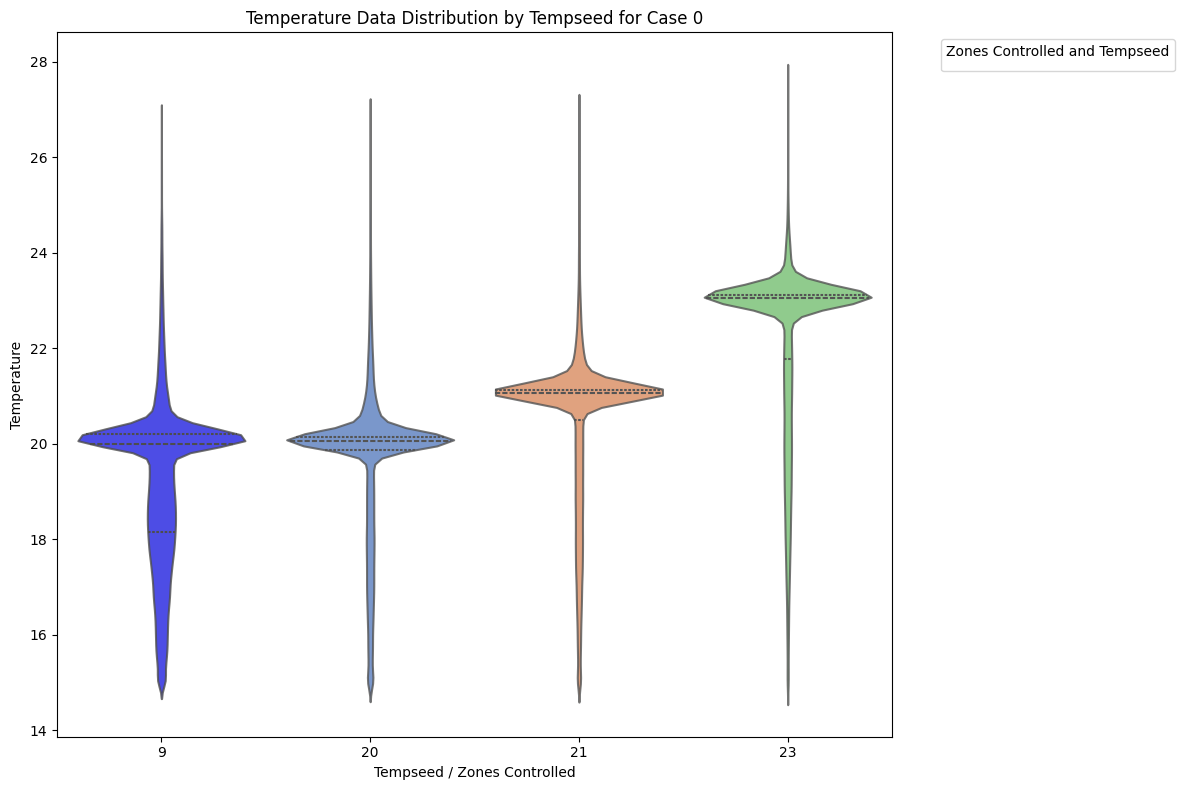

In [49]:
df_opr = pd.read_pickle("/workspaces/CUBES/exp/jack/paper/thermostat_experiment/analysis/final_runs_v2_Zone_Operative_Temperature_temperature_distribution.pkl")
df_case0 = df_opr[(df_opr['case'] == "0") & ((df_opr['zones_controlled'] == "0") | (df_opr['zones_controlled'] == "9"))]
df_flat = df_case0.explode('temp_data')

mapping = {"15": 23, "30": 21, "42": 20}
df_flat['tempseed_mapped'] = df_flat['tempseed'].map(mapping)
df_flat_sorted = df_flat.sort_values(by='tempseed_mapped')

# Separate data
data_zones_9 = df_flat_sorted[df_flat_sorted['zones_controlled'] == "9"]
data_zones_0 = df_flat_sorted[df_flat_sorted['zones_controlled'] == "0"]

plt.figure(figsize=(12, 8))

# Plot zones_controlled == 9
sns.violinplot(
    x='zones_controlled',
    y='temp_data',
    data=data_zones_9,
    inner='quart',
    linewidth=1.5,
    alpha=0.8,
    color='blue'
)

# Plot zones_controlled == 0 for each tempseed_mapped
sns.violinplot(
    x='tempseed_mapped',
    y='temp_data',
    data=data_zones_0,
    inner='quart',
    linewidth=1.5,
    alpha=0.8,
    palette='muted'
)

plt.title('Temperature Data Distribution by Tempseed for Case 0')
plt.xlabel('Tempseed / Zones Controlled')
plt.ylabel('Temperature')
plt.legend(title='Zones Controlled and Tempseed', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


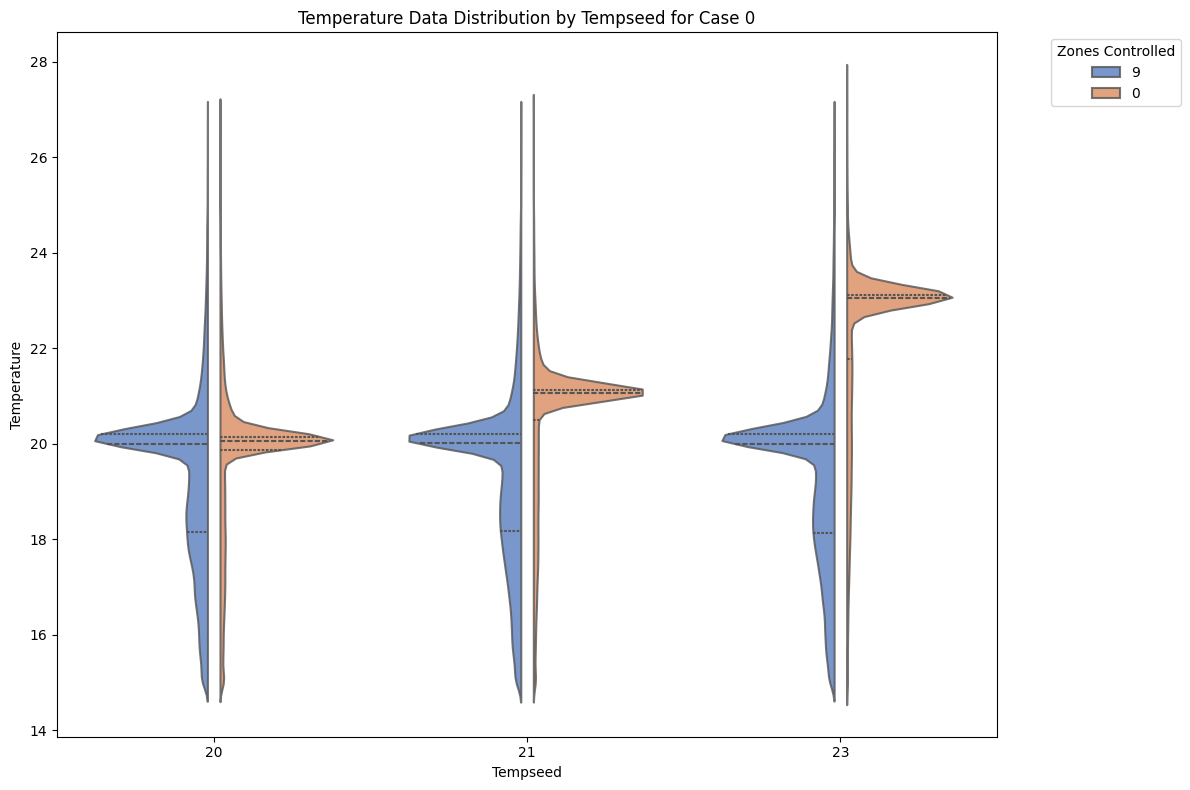

In [50]:
df_opr = pd.read_pickle("/workspaces/CUBES/exp/jack/paper/thermostat_experiment/analysis/final_runs_v2_Zone_Operative_Temperature_temperature_distribution.pkl")
df_case0 = df_opr[(df_opr['case'] == "0") & ((df_opr['zones_controlled'] == "0") | (df_opr['zones_controlled'] == "9"))]
df_flat = df_case0.explode('temp_data')

# Define the mapping dictionary
mapping = {
    "15": 23,
    "30": 21,
    "42": 20
}

# Apply the mapping
df_flat['tempseed_mapped'] = df_flat['tempseed'].map(mapping)

# Sort by the new mapped values
df_flat_sorted = df_flat.sort_values(by='tempseed_mapped')

# Plotting using seaborn
plt.figure(figsize=(12, 8))

# Create violin plot with enhanced appearance
sns.violinplot(
    x='tempseed_mapped',
    y='temp_data',
    hue='zones_controlled',
    data=df_flat_sorted,
    inner='quart',
    #inner='box',
    #inner_kws=dict(box_width=5, whis_width=2, color=".8"),
    split=True,
    gap=.1,
    palette='muted',  # Change the palette to enhance colors
    linewidth=1.5,    # Increase the edge line width
    alpha=0.8         # Set transparency to make the plot stand out more
)

plt.title('Temperature Data Distribution by Tempseed for Case 0')
plt.xlabel('Tempseed')
plt.ylabel('Temperature')
plt.legend(title='Zones Controlled', bbox_to_anchor=(1.05, 1), loc='upper left')  # Adjust legend position
plt.tight_layout()  # Adjust layout to fit the legend
plt.show()

In [54]:
case = "0"
tempseed =  ["42", "15", "30"]
onoffseed = ["5", "10", "15"]

In [58]:
rando = case0["temp_data"].values.flatten()

In [127]:
case0_uncontrolled_data = []
case0_controlled_data = []
case0_semicontrolled_data = []

df = df_opr

for ts in tempseed:
    case0 = df[(df["case"] == case) & (df["tempseed"] == ts)]

    case0_uncontrolled = case0[(case0["zones_controlled"] == "0")]
    case0_controlled = case0[(case0["zones_controlled"] == "9")]
    case0_semicontrolled = case0[(case0["zones_controlled"] == "4")]

    case0_uncontrolled = np.concatenate(case0_uncontrolled["temp_data"].values).flatten()
    case0_controlled = np.concatenate(case0_controlled["temp_data"].values).flatten()
    case0_semicontrolled = np.concatenate(case0_semicontrolled["temp_data"].values).flatten()

    case0_uncontrolled_data.extend(case0_uncontrolled[~np.isnan(case0_uncontrolled)])
    case0_controlled_data.extend(case0_controlled[~np.isnan(case0_controlled)])
    case0_semicontrolled_data.extend(case0_semicontrolled[~np.isnan(case0_semicontrolled)])

# Convert lists to NumPy arrays
case0_uncontrolled_data = np.array(case0_uncontrolled_data)
case0_controlled_data = np.array(case0_controlled_data)
case0_semicontrolled_data = np.array(case0_semicontrolled_data)

print("Case 0 Uncontrolled Data:", case0_uncontrolled_data)
print("Case 0 Controlled Data:", case0_controlled_data)
print("Case 0 Semi-Controlled Data:", case0_semicontrolled_data)

Case 0 Uncontrolled Data: [20.028336 20.00536  20.243021 ... 21.072016 21.051857 21.067417]
Case 0 Controlled Data: [16.915575 17.914942 18.371063 ... 20.26511  15.194033 18.640982]
Case 0 Semi-Controlled Data: [20.047413 18.560678 20.205688 ... 21.04186  16.533293 21.035868]


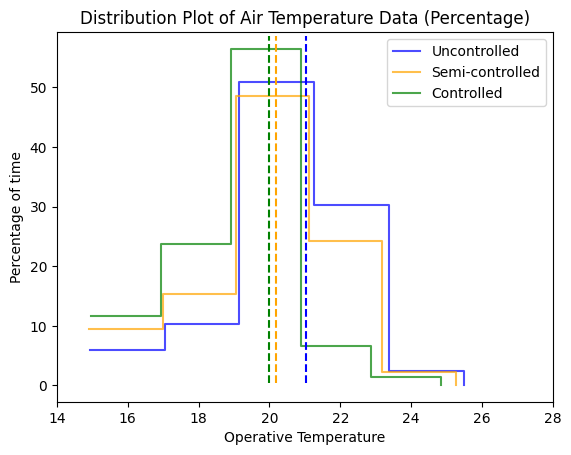

In [133]:
bins = 6

# Plot for controlled case
hist_data_controlled = case0_controlled_data
count_controlled, bins_controlled, _ = plt.hist(hist_data_controlled, bins=bins, alpha=0.7, density=True)
count_percentage_controlled = count_controlled / count_controlled.sum() * 100

# Plot for semi-controlled case
hist_data_semicontrolled = case0_semicontrolled_data
count_semicontrolled, bins_semicontrolled, _ = plt.hist(hist_data_semicontrolled, bins=bins, alpha=0.7, density=True)
count_percentage_semicontrolled = count_semicontrolled / count_semicontrolled.sum() * 100

# Plot for uncontrolled case
hist_data_uncontrolled = case0_uncontrolled_data
count_uncontrolled, bins_uncontrolled, _ = plt.hist(hist_data_uncontrolled, bins=bins, alpha=0.7, density=True)
count_percentage_uncontrolled = count_uncontrolled / count_uncontrolled.sum() * 100
plt.clf()  # Clear the current plot

# Plot all on the same plot with clearer colours
plt.plot(bins_uncontrolled[:-1], count_percentage_uncontrolled, drawstyle='steps-post', alpha=0.7, label='Uncontrolled', color='blue')
plt.plot(bins_semicontrolled[:-1], count_percentage_semicontrolled, drawstyle='steps-post', alpha=0.7, label='Semi-controlled', color='orange')
plt.plot(bins_controlled[:-1], count_percentage_controlled, drawstyle='steps-post', alpha=0.7, label='Controlled', color='green')

plt.axvline(x=21.02,ymin=0.05, ymax=0.99, color="blue", linestyle="--")
plt.axvline(x=20.18,ymin=0.05, ymax=0.99, color="orange", linestyle="--")
plt.axvline(x=20.00,ymin=0.05, ymax=0.99, color="green", linestyle="--")

plt.xlim([14,28])

plt.xlabel('Operative Temperature')
plt.ylabel('Percentage of time')
plt.title('Distribution Plot of Air Temperature Data (Percentage)')
plt.legend()
plt.show()


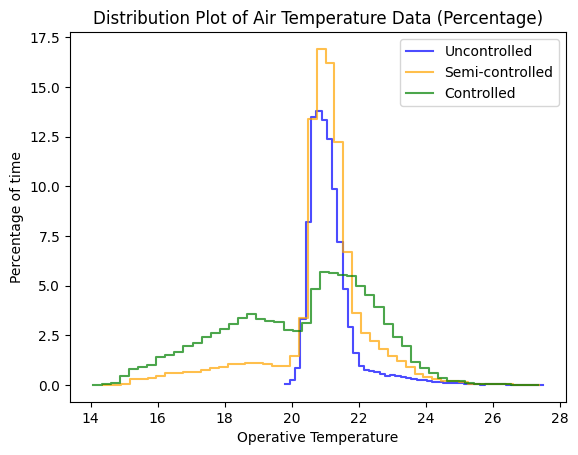

In [51]:
df = df_air

case0 = df[(df["case"] == case) & (df["year"] == "2022")]
case0_uncontrolled = case0[(case0["zones_controlled"] == "0") & (case0["onoffseed"] == onoffseed) & (case0["tempseed"] == tempseed)]
case0_controlled = case0[(case0["zones_controlled"] == "9") & (case0["onoffseed"] == onoffseed) & (case0["tempseed"] == tempseed)]
case0_semicontrolled = case0[(case0["zones_controlled"] == "4") & (case0["onoffseed"] == onoffseed) & (case0["tempseed"] == tempseed)]

bins = 50

# Plot for controlled case
hist_data_controlled = case0_controlled["temp_data"]
count_controlled, bins_controlled, _ = plt.hist(hist_data_controlled, bins=bins, alpha=0.7, density=True)
count_percentage_controlled = count_controlled / count_controlled.sum() * 100

# Plot for semi-controlled case
hist_data_semicontrolled = case0_semicontrolled["temp_data"]
count_semicontrolled, bins_semicontrolled, _ = plt.hist(hist_data_semicontrolled, bins=bins, alpha=0.7, density=True)
count_percentage_semicontrolled = count_semicontrolled / count_semicontrolled.sum() * 100

# Plot for uncontrolled case
hist_data_uncontrolled = case0_uncontrolled["temp_data"]
count_uncontrolled, bins_uncontrolled, _ = plt.hist(hist_data_uncontrolled, bins=bins, alpha=0.7, density=True)
count_percentage_uncontrolled = count_uncontrolled / count_uncontrolled.sum() * 100
plt.clf()  # Clear the current plot

# Plot all on the same plot with clearer colours
plt.plot(bins_uncontrolled[:-1], count_percentage_uncontrolled, drawstyle='steps-post', alpha=0.7, label='Uncontrolled', color='blue')
plt.plot(bins_semicontrolled[:-1], count_percentage_semicontrolled, drawstyle='steps-post', alpha=0.7, label='Semi-controlled', color='orange')
plt.plot(bins_controlled[:-1], count_percentage_controlled, drawstyle='steps-post', alpha=0.7, label='Controlled', color='green')

plt.xlabel('Operative Temperature')
plt.ylabel('Percentage of time')
plt.title('Distribution Plot of Air Temperature Data (Percentage)')
plt.legend()
plt.show()


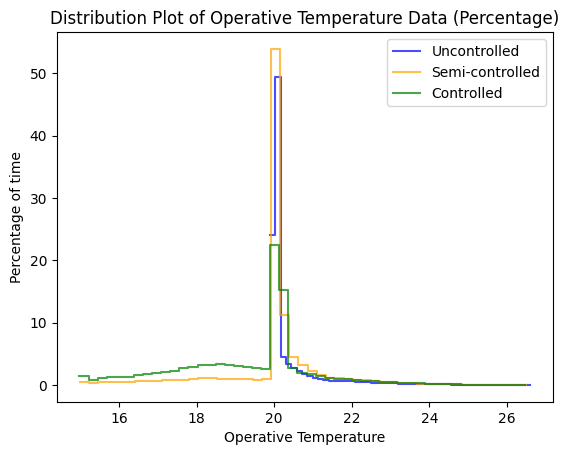

In [53]:
df = df_opr

case0 = df[(df["case"] == case) & (df["year"] == "2022")]
case0_uncontrolled = case0[(case0["zones_controlled"] == "0") & (case0["onoffseed"] == onoffseed) & (case0["tempseed"] == tempseed)]
case0_controlled = case0[(case0["zones_controlled"] == "9") & (case0["onoffseed"] == onoffseed) & (case0["tempseed"] == tempseed)]
case0_semicontrolled = case0[(case0["zones_controlled"] == "4") & (case0["onoffseed"] == onoffseed) & (case0["tempseed"] == tempseed)]

bins = 50

# Plot for controlled case
hist_data_controlled = case0_controlled["temp_data"]
count_controlled, bins_controlled, _ = plt.hist(hist_data_controlled, bins=bins, alpha=0.7, density=True)
count_percentage_controlled = count_controlled / count_controlled.sum() * 100

# Plot for semi-controlled case
hist_data_semicontrolled = case0_semicontrolled["temp_data"]
count_semicontrolled, bins_semicontrolled, _ = plt.hist(hist_data_semicontrolled, bins=bins, alpha=0.7, density=True)
count_percentage_semicontrolled = count_semicontrolled / count_semicontrolled.sum() * 100

# Plot for uncontrolled case
hist_data_uncontrolled = case0_uncontrolled["temp_data"]
count_uncontrolled, bins_uncontrolled, _ = plt.hist(hist_data_uncontrolled, bins=bins, alpha=0.7, density=True)
count_percentage_uncontrolled = count_uncontrolled / count_uncontrolled.sum() * 100
plt.clf()  # Clear the current plot

# Plot all on the same plot with clearer colours
plt.plot(bins_uncontrolled[:-1], count_percentage_uncontrolled, drawstyle='steps-post', alpha=0.7, label='Uncontrolled', color='blue')
plt.plot(bins_semicontrolled[:-1], count_percentage_semicontrolled, drawstyle='steps-post', alpha=0.7, label='Semi-controlled', color='orange')
plt.plot(bins_controlled[:-1], count_percentage_controlled, drawstyle='steps-post', alpha=0.7, label='Controlled', color='green')

plt.xlabel('Operative Temperature')
plt.ylabel('Percentage of time')
plt.title('Distribution Plot of Operative Temperature Data (Percentage)')
plt.legend()
plt.show()


In [118]:
retrofit_colours = ['#3e7ad3', '#518dca', '#5ba0c0', '#5fb4b5', '#f1a800']
baseline_colours = ['#3e7ad3']
control_colours =  ['#005c83', '#1d82ab', '#33a9d4']
fabric_colours = ['#674b00', '#906f00', '#bc9400', '#eabc17'] #['#3DDBD9', '#3DDBD9', '#3DDBD9', '#3DDBD9']
energy_colours = ['#7b0044', '#ff7eb6'] #['#82CFFF', '#82CFFF']
combo_colours =  ['#6746a6', '#a67ee6', '#ecc0ff'] #['#110158', '#6947a8', '#be95ff'] #['#BE95FF', '#BE95FF', '#BE95FF']

intermediate_colors = baseline_colours + control_colours + fabric_colours + energy_colours + combo_colours

full_custom_labels = ['Baseline',
                      'Control - One Zone',
                 'Control - Four zones',
                 'Control - All zones',
                 'Fabric - Low cost',
                 'Fabric - Shallow',
                 'Fabric - Deep',
                 'Fabric - Passivhaus',
                 'System\nASHP',
                 'System\nASHP + PV/Batt',
                 'Combo\nPassivhaus + All Control',
                 'Combo\nEnergy System + All Control',
                 'Combo\nBest Fabric & System + All Control']

custom_labels = ['+ One zone controlled',
                '+ Four zones controlled',
                 '+ All zones controlled',
                 'Baseline + Low cost',
                 '+ Shallow',
                 '+ Deep',
                 '+ Passivhaus',
                 'Baseline + ASHP',
                 '+ PV/Batt',
                 'Passivhaus + All Control',
                 'Energy System + All Control',
                 'Best Fabric & System + All Control']

def align_yaxis(ax1, ax2):
    """Align zeros of the two axes, zooming them out by same ratio"""
    axes = (ax1, ax2)
    extrema = [ax.get_ylim() for ax in axes]
    tops = [extr[1] / (extr[1] - extr[0]) for extr in extrema]
    # Ensure that plots (intervals) are ordered bottom to top:
    if tops[0] > tops[1]:
        axes, extrema, tops = [list(reversed(l)) for l in (axes, extrema, tops)]

    # How much would the plot overflow if we kept current zoom levels?
    tot_span = tops[1] + 1 - tops[0]

    b_new_t = extrema[0][0] + tot_span * (extrema[0][1] - extrema[0][0])
    t_new_b = extrema[1][1] - tot_span * (extrema[1][1] - extrema[1][0])
    axes[0].set_ylim(extrema[0][0], b_new_t)
    axes[1].set_ylim(t_new_b, extrema[1][1])

In [106]:
def combine_results():

    # Directory where your CSV files are located
    directory = "/workspaces/CUBES/exp/jack/paper/thermostat_experiment/Eplus_files/final_runs_v0"

    # Pattern to match the CSV files
    file_pattern = '*final_runs_v2-res1_progress.csv'

    # Find all matching file paths
    file_paths = glob.glob(os.path.join(directory, file_pattern))

    # List to hold all DataFrames
    dfs = []

    # Read each CSV file into a DataFrame, add filename as a column, and store in dfs list
    for file_path in file_paths:
        try:
            # Read CSV file into DataFrame
            df = pd.read_csv(file_path)

            # Extract filename from file_path
            filename = os.path.basename(file_path)

            filename = filename.split("thermostat_rbc_eco_case_0_")[-1]

            df["year"] = filename.split("year_")[-1].split("_")[0]
            df["case"] = filename.split("case_")[-1].split("_")[0]
            df["rep"] = filename.split("rep_")[-1].split("_")[0]
            df["zones_controlled"] = filename.split("zone_")[-1].split("_")[0]
            df["onoffseed"] = filename.split("onoffseed_")[-1].split("_")[0]
            df["tempseed"] = filename.split("tempseed_")[-1].split("_")[0]
            # Add filename as a column
            df['filename'] = filename

            # Append DataFrame to dfs list
            dfs.append(df)
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

    # Check if dfs list is empty
    if not dfs:
        print("No DataFrames were created. Exiting.")
    else:
        # Concatenate all DataFrames into a single DataFrame
        combined_df = pd.concat(dfs, ignore_index=True)

        # Print some information
        print(f"Total CSV files read: {len(dfs)}")
        print(f"Combined DataFrame shape: {combined_df.shape}")

    return combined_df


def gather_raw_and_clean():
    df = pd.read_csv("/workspaces/CUBES/exp/jack/paper/thermostat_experiment/Eplus_files/final_runs_v0/final_runs_v2.csv",index_col=0)

    results_condensed = df[['year',
                        'case',
                        'rep',
                        'zones_controlled',
                        'onoffseed',
                        'tempseed',
                        "cost",
                        'cumulative_emissions',
                        'comfort_violation (%)',
                        'mean_comfort_violation',
                        'std_comfort_violation']]


    #years = [2022,2023]
    #cases = [0,1,2,3,4,5,10]
    #controls = [0,4,9]
#
    ## List to collect the results
    #results_list = []
#
    #for year in years:
    #    for case in cases:
    #        baseline = results_condensed[(results_condensed["year"] == year) & (results_condensed["case"] == 0) & (results_condensed["zones_controlled"] == 0)].mean()
    #        baseline_cost = baseline["cost"]/100
    #        baseline_emissions = baseline["cumulative_emissions"]/1000
    #        for control in controls:
    #            temp_df = results_condensed[(results_condensed["year"] == year) & (results_condensed["case"] == case) & (results_condensed["zones_controlled"] == control)]
#
    #            if not temp_df.empty:
#
    #                mean_emissions = temp_df["cumulative_emissions"].mean() / 1000 # Convert to tCO2
#
    #                mean_cost = temp_df["cost"].mean() / 100                # Convert from p to £
#
    #                mean_comfort = temp_df["comfort_violation (%)"].mean()
#
#
    #                relative_emissions = (100*(1-(baseline_emissions - mean_emissions)/baseline_emissions)) -100
    #                relative_cost =  100* ((mean_cost - baseline_cost)/ baseline_cost)
    #                relative_comfort = (100*(1-(baseline["comfort_violation (%)"] - mean_comfort)/baseline["comfort_violation (%)"])) - 100
#
    #                # Collect the results in a dictionary
    #                results_list.append({
    #                    'year': year,
    #                    'case': case,
    #                    'zones_controlled': control,
    #                    'relative_emissions': relative_emissions,
    #                    'relative_cost': relative_cost,
    #                    'relative_discomfort': relative_comfort
    #                })
#
    ## Convert the list of dictionaries to a DataFrame
    #master_df = pd.DataFrame(results_list)


    # Define building_cost_df
    building_cost = {
        'case': [0, 1, 2, 3, 4, 5, 10],
        'building_cost': [0, 3800, 16000, 51000, 71000, 28000, 48000]
    }
    building_cost_df = pd.DataFrame(building_cost)

    # Define sensing_cost_df
    sensing_cost = {
        'zones_controlled': [0, 1, 4, 9],
        'sensing_cost': [0,60, 240, 520],
        'control_names': ["Manual Control","One Zone Controlled", "Partial Control", "Full Control"]
    }
    sensing_cost_df = pd.DataFrame(sensing_cost)

    # Define sensing_cost_df
    case_names = {
        'case': [0, 1, 2, 3, 4, 5, 10],
        'retrofit_name': ["Baseline", "Fabric - Low cost", "Fabric - Shallow", "Fabric - Deep", "Fabric - Passivhaus", "System - ASHP", "System - ASHP+PV+Batt"],
    }
    case_names_df = pd.DataFrame(case_names)

    # Merge building_cost_df with master_df
    merged_df = pd.merge(results_condensed, building_cost_df, on='case', how='left')

    # Merge sensing_cost_df with merged_df
    merged_df = pd.merge(merged_df, sensing_cost_df, on='zones_controlled', how='left')

    merged_df = pd.merge(merged_df, case_names_df, on='case', how='left')

    # Optionally, rename columns if needed
    merged_df.rename(columns={'building_cost_x': 'building_cost'}, inplace=True)

    merged_df["installation_cost"] = merged_df["building_cost"] + merged_df["sensing_cost"]

    merged_df["name"] = merged_df['retrofit_name'] + " " + merged_df['control_names']

    merged_df["cumulative_emissions"] = merged_df["cumulative_emissions"] / 1000
    merged_df["cost"] = merged_df["cost"] / 100

    df_2022 = merged_df[merged_df["year"] == 2022]
    df_2023 = merged_df[merged_df["year"] == 2023]

    df_2022 = df_2022.reset_index()
    df_2023 = df_2023.reset_index()


    df_2022 = df_2022.groupby(
    ["case", "zones_controlled", "name", "retrofit_name", "installation_cost"]
        ).agg(
            mean_emissions=('cumulative_emissions', 'mean'),
            std_emissions=('cumulative_emissions', 'std'),
            mean_cost=('cost', 'mean'),
            std_cost=('cost', 'std'),
            mean_comfort=('comfort_violation (%)', 'mean'),
            std_comfort=('comfort_violation (%)', 'std')
        ).reset_index()

    df_2023 = df_2023.groupby(
    ["case", "zones_controlled", "name", "retrofit_name", "installation_cost"]
        ).agg(
            mean_emissions=('cumulative_emissions', 'mean'),
            std_emissions=('cumulative_emissions', 'std'),
            mean_cost=('cost', 'mean'),
            std_cost=('cost', 'std'),
            mean_comfort=('comfort_violation (%)', 'mean'),
            std_comfort=('comfort_violation (%)', 'std')
        ).reset_index()


    df_2022["bill_saving"] = -1 * (df_2022["mean_cost"].loc[:] - df_2022["mean_cost"].iloc[0])

    df_2022["payback"] = df_2022["installation_cost"].loc[:] / df_2022["bill_saving"].loc[:]

    df_2023["bill_saving"] = -1 * (df_2023["mean_cost"] - df_2023["mean_cost"].iloc[0])

    df_2023["payback"] = df_2023["installation_cost"] / df_2023["bill_saving"]

    df_2022["relative_emissions"] = (1 - (df_2022["mean_emissions"] / df_2022["mean_emissions"].iloc[0])) * -100
    df_2022["relative_emissions_std"] = (df_2022["std_emissions"] / df_2022["mean_emissions"].loc[0]) *100

    df_2022["relative_cost"] = ((df_2022["mean_cost"] - df_2022["mean_cost"].iloc[0]) / df_2022["mean_cost"].iloc[0]) * 100
    df_2022["relative_cost_std"] = (df_2022["std_cost"] / df_2022["mean_cost"].loc[0]) *100


    df_2023["relative_cost"] = ((df_2023["mean_cost"] - df_2023["mean_cost"].iloc[0]) / df_2023["mean_cost"].iloc[0]) * 100
    df_2023["relative_cost_std"] = (df_2023["std_cost"] / df_2023["mean_cost"].loc[0]) *100

    df_2023["relative_emissions"] = (1 - (df_2023["mean_emissions"] / df_2023["mean_emissions"].iloc[0])) * -100
    df_2023["relative_emissions_std"] = (df_2023["std_emissions"] / df_2023["mean_emissions"].loc[0]) *100


    # Assuming master_df is your DataFrame
    # Group by specified columns and calculate both mean and standard deviation
    combined = merged_df.groupby(
        ["case", "zones_controlled", "name", "retrofit_name", "installation_cost"]
    ).agg(
        mean_emissions=('cumulative_emissions', 'mean'),
        std_emissions=('cumulative_emissions', 'std'),
        mean_cost=('cost', 'mean'),
        std_cost=('cost', 'std'),
        mean_comfort=('comfort_violation (%)', 'mean'),
        std_comfort=('comfort_violation (%)', 'std')
    ).reset_index()

    combined["bill_saving"] = -1 * (combined["mean_cost"] - combined["mean_cost"].iloc[0])

    combined["payback"] = combined["installation_cost"] / combined["bill_saving"]

    combined["relative_emissions"] = (1 - (combined["mean_emissions"] / combined["mean_emissions"].iloc[0])) * -100
    combined["relative_emissions_std"] = (combined["std_emissions"] / combined["mean_emissions"].loc[0]) *100

    combined["relative_cost"] = ((combined["mean_cost"] - combined["mean_cost"].iloc[0]) / combined["mean_cost"].iloc[0]) * 100
    combined["relative_cost_std"] = (combined["std_cost"] / combined["mean_cost"].loc[0]) *100

    return merged_df, combined, df_2022, df_2023





In [6]:
df = combine_results()
df.to_csv("/workspaces/CUBES/exp/jack/paper/thermostat_experiment/Eplus_files/final_runs_v0/final_runs_v2.csv")


Total CSV files read: 450
Combined DataFrame shape: (450, 30)


In [96]:
master, combined, df_2022, df_2023 = gather_raw_and_clean()

In [97]:
combined

,case,zones_controlled,name,retrofit_name,installation_cost,mean_emissions,std_emissions,mean_cost,std_cost,mean_comfort,std_comfort,bill_saving,payback,relative_emissions,relative_emissions_std,relative_cost,relative_cost_std
0,0,0,Baseline Manual Control,Baseline,0.000,4.186,0.734,1594.398,483.944,16.256,10.970,-0.000,NaN,-0.000,17.541,0.000,30.353
1,0,1,Baseline One Zone Controlled,Baseline,60.000,3.958,0.642,1509.593,447.226,17.071,10.868,84.805,0.708,-5.449,15.338,-5.319,28.050
2,0,4,Baseline Partial Control,Baseline,240.000,3.525,0.393,1351.497,368.882,18.518,9.376,242.901,0.988,-15.793,9.392,-15.235,23.136
3,0,9,Baseline Full Control,Baseline,520.000,2.957,0.005,1144.484,287.953,11.785,0.570,449.914,1.156,-29.374,0.114,-28.218,18.060
4,1,0,Fabric - Low cost Manual Control,Fabric - Low cost,3800.000,4.007,0.702,1524.610,462.386,16.374,11.094,69.788,54.451,-4.279,16.764,-4.377,29.001
5,1,4,Fabric - Low cost Partial Control,Fabric - Low cost,4040.000,3.372,0.378,1290.930,352.317,20.097,9.254,303.468,13.313,-19.461,9.034,-19.033,22.097
6,1,9,Fabric - Low cost Full Control,Fabric - Low cost,4320.000,2.823,0.004,1091.096,274.071,15.454,0.604,503.303,8.583,-32.568,0.107,-31.567,17.190
7,2,0,Fabric - Shallow Manual Control,Fabric - Shallow,16000.000,3.305,0.573,1259.387,383.271,15.787,11.109,335.011,47.760,-21.051,13.692,-21.012,24.039
8,2,4,Fabric - Shallow Partial Control,Fabric - Shallow,16240.000,2.770,0.311,1061.209,291.842,22.351,8.674,533.190,30.458,-33.829,7.441,-33.441,18.304
9,2,9,Fabric - Shallow Full Control,Fabric - Shallow,16520.000,2.313,0.000,893.715,226.412,21.449,0.624,700.683,23.577,-44.742,0.010,-43.947,14.200


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
names = ["Manual Control", "Partial Control", "Full Control"]
mean_emissions = combined["mean_emissions"]
std_emissions = combined["std_emissions"]

# X-axis positions
x_pos = np.arange(len(names))

# Create the bar plot
fig, ax = plt.subplots()
bars = ax.bar(x_pos, mean_emissions, yerr=std_emissions, align='center', alpha=0.7, ecolor='black', capsize=10)

# Add labels and title
ax.set_xlabel('Control Type')
ax.set_ylabel('Mean Emissions')
ax.set_title('Mean Emissions by Control Type with Standard Deviation')
ax.set_xticks(x_pos)
ax.set_xticklabels(names)
ax.yaxis.grid(True)

# Save and display the plot
plt.tight_layout()
plt.show()


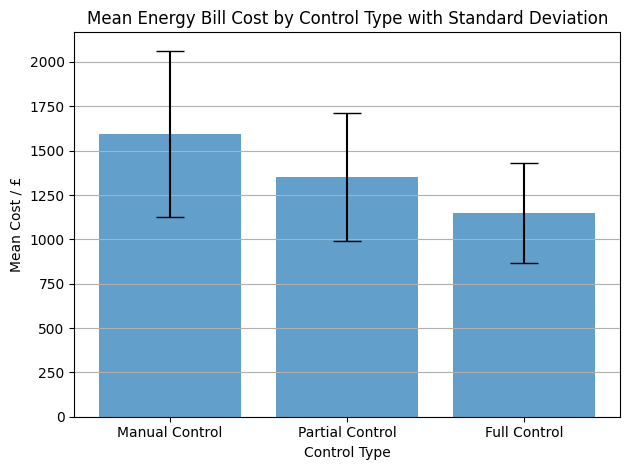

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
names = ["Manual Control", "Partial Control", "Full Control"]
mean_emissions = combined["mean_cost"]
std_emissions = combined["std_cost"]

# X-axis positions
x_pos = np.arange(len(names))

# Create the bar plot
fig, ax = plt.subplots()
bars = ax.bar(x_pos, mean_emissions, yerr=std_emissions, align='center', alpha=0.7, ecolor='black', capsize=10)

# Add labels and title
ax.set_xlabel('Control Type')
ax.set_ylabel('Mean Cost / £')
ax.set_title('Mean Energy Bill Cost by Control Type with Standard Deviation')
ax.set_xticks(x_pos)
ax.set_xticklabels(names)
ax.yaxis.grid(True)

# Save and display the plot
plt.tight_layout()
plt.show()


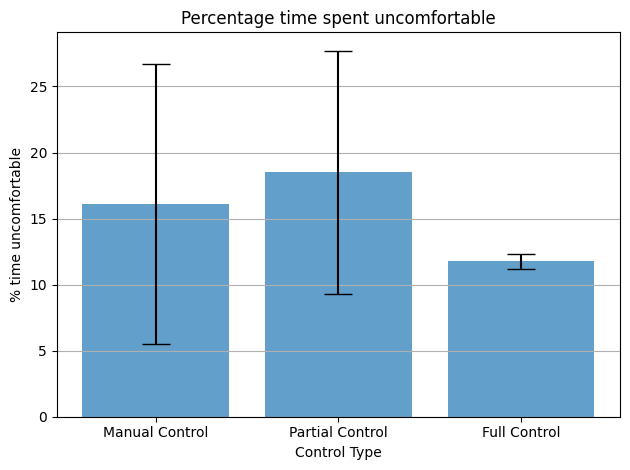

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
names = ["Manual Control", "Partial Control", "Full Control"]
mean_emissions = combined["mean_comfort"]
std_emissions = combined["std_comfort"]

# X-axis positions
x_pos = np.arange(len(names))

# Create the bar plot
fig, ax = plt.subplots()
bars = ax.bar(x_pos, mean_emissions, yerr=std_emissions, align='center', alpha=0.7, ecolor='black', capsize=10)

# Add labels and title
ax.set_xlabel('Control Type')
ax.set_ylabel('% time uncomfortable')
ax.set_title('Percentage time spent uncomfortable')
ax.set_xticks(x_pos)
ax.set_xticklabels(names)
ax.yaxis.grid(True)

# Save and display the plot
plt.tight_layout()
plt.show()


### Plotting Bar Chart of percentage change in emissions and cost

#### For combined 2022 and 2023

In [55]:
combined

,case,zones_controlled,name,retrofit_name,installation_cost,mean_emissions,std_emissions,mean_cost,std_cost,mean_comfort,std_comfort,bill_saving,payback,relative_emissions,relative_emissions_std,relative_cost,relative_cost_std
0,0,0,Baseline Manual Control,Baseline,0,3.509,0.127,1349.271,330.724,10.735,1.559,-0.000,NaN,-0.000,3.627,0.000,24.511
1,0,4,Baseline Partial Control,Baseline,240,3.261,0.053,1258.017,307.157,10.105,1.118,91.254,2.630,-7.046,1.509,-6.763,22.765
2,0,9,Baseline Full Control,Baseline,520,3.098,0.005,1199.071,293.880,8.932,0.707,150.200,3.462,-11.702,0.144,-11.132,21.781
3,1,0,Fabric - Low cost Manual Control,Fabric - Low cost,3800,3.313,0.117,1272.733,311.611,11.942,1.523,76.537,49.649,-5.574,3.327,-5.673,23.095
4,1,4,Fabric - Low cost Partial Control,Fabric - Low cost,4040,3.084,0.049,1188.085,289.719,11.862,1.132,161.185,25.064,-12.094,1.400,-11.946,21.472
5,1,9,Fabric - Low cost Full Control,Fabric - Low cost,4320,2.931,0.004,1132.654,277.130,11.093,0.787,216.617,19.943,-16.458,0.126,-16.054,20.539
6,2,0,Fabric - Shallow Manual Control,Fabric - Shallow,16000,2.630,0.086,1013.071,251.383,14.866,1.290,336.200,47.591,-25.039,2.450,-24.917,18.631
7,2,4,Fabric - Shallow Partial Control,Fabric - Shallow,16240,2.451,0.036,945.817,233.688,16.314,1.010,403.454,40.252,-30.152,1.012,-29.902,17.320
8,2,9,Fabric - Shallow Full Control,Fabric - Shallow,16520,2.337,0.002,904.117,223.812,15.712,0.869,445.154,37.111,-33.380,0.061,-32.992,16.588
9,3,0,Fabric - Deep Manual Control,Fabric - Deep,51000,1.227,0.276,624.401,181.772,11.895,7.992,724.870,70.357,-65.038,7.864,-53.723,13.472


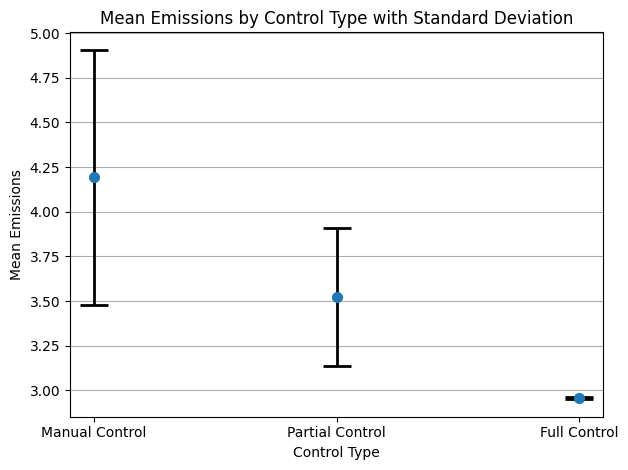

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
names = ["Manual Control", "Partial Control", "Full Control"]
mean_emissions = [4.193, 3.525, 2.956]
std_emissions = [0.713, 0.386, 0.005]

# X-axis positions
x_pos = np.arange(len(names))

# Create the scatter plot with error bars
fig, ax = plt.subplots()
ax.errorbar(x_pos, mean_emissions, yerr=std_emissions, fmt='o', ecolor='black', capsize=10, elinewidth=2, markeredgewidth=2)

# Add labels and title
ax.set_xlabel('Control Type')
ax.set_ylabel('Mean Emissions')
ax.set_title('Mean Emissions by Control Type with Standard Deviation')
ax.set_xticks(x_pos)
ax.set_xticklabels(names)
ax.yaxis.grid(True)

# Save and display the plot
plt.tight_layout()
plt.show()


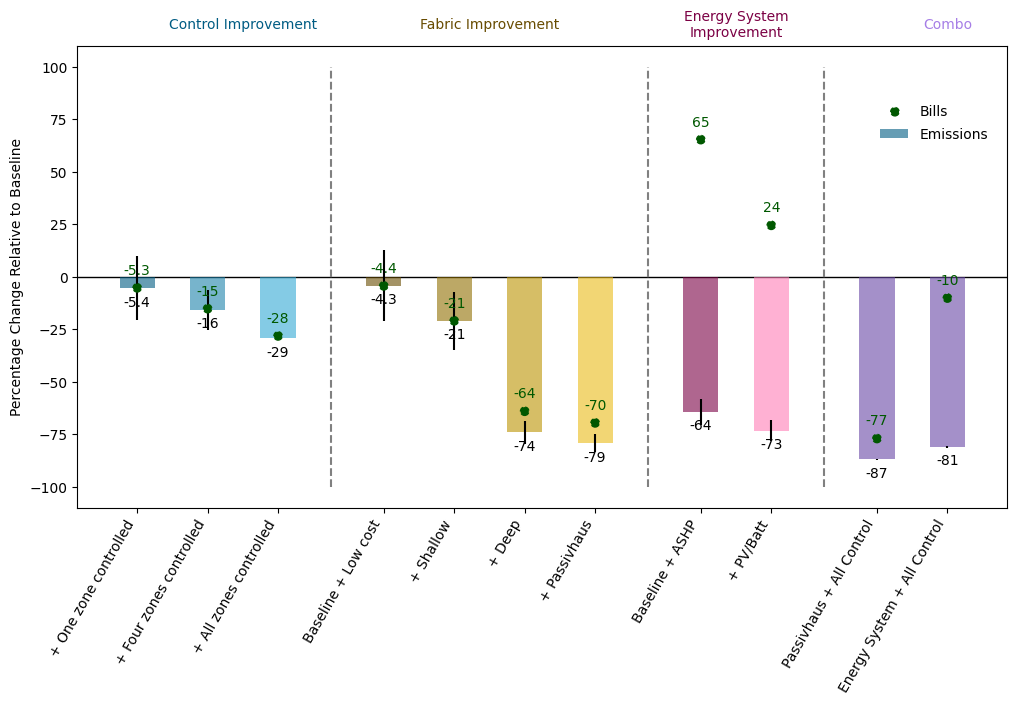

In [123]:
# Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))


control_df = combined[(combined["case"] == 0) & (combined["zones_controlled"] > 0)]
fabric_df = combined[(combined["case"] < 5) &  (combined["case"] > 0)& (combined["zones_controlled"] == 0)]
system_df =  combined[(combined["case"] > 4 ) &  (combined["case"] < 14 ) & (combined["zones_controlled"] == 0)]
best_df = combined[((combined["case"] == 4 ) | (combined["case"] == 10 )) & (combined["zones_controlled"] == 9)]

#bars = ax.bar(x_pos, mean_emissions, yerr=std_emissions, align='center', alpha=0.7, ecolor='black', capsize=10)



control = control_df["relative_emissions"]
fabric = fabric_df["relative_emissions"]
system = system_df["relative_emissions"]
best = best_df["relative_emissions"]

control_std = control_df["relative_emissions_std"]
fabric_std = fabric_df["relative_emissions_std"]
system_std = system_df["relative_emissions_std"]
best_std = best_df["relative_emissions_std"]

savings_control =control_df["relative_cost"]
savings_fabric =fabric_df["relative_cost"]
savings_system =system_df["relative_cost"]
savings_best =best_df["relative_cost"]

savings_control_std = control_df["relative_cost_std"]
savings_fabric_std = fabric_df["relative_cost_std"]
savings_system_std = system_df["relative_cost_std"]
savings_best_std = best_df["relative_cost_std"]

range1 = np.arange(0,3)+0.5
range2 = np.arange(3,7)+1
range3 = np.arange(7,9)+1.5
range4 = np.arange(9,11)+2

ranges_concatenated = np.concatenate([range1,range2,range3,range4])

# Plot bars
#base = ax1.bar(np.arange(1), savings_baselines, color=intermediate_colors[0], width=0.5, alpha=0.6, label='Baseline')
cont = ax1.bar(range1, control, yerr=control_std, color=intermediate_colors[1:4], width=0.5, alpha=0.6, label='Emissions')
fab = ax1.bar(range2, fabric, yerr=fabric_std, color=intermediate_colors[4:8], width=0.5, alpha=0.6)
sys = ax1.bar(range3, system, yerr=system_std, color=intermediate_colors[8:10], width=0.5, alpha=0.6)
bes = ax1.bar(range4, best, yerr=best_std, color=intermediate_colors[10:11], width=0.5, alpha=0.6)

# Add data labels
for bar in cont:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height - 10, f'{height:.2g}', color='black', ha='center', va='bottom')
for bar in fab:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height - 10, f'{height:.2g}', color='black', ha='center', va='bottom')

for bar in sys:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height - 10, f'{height:.2g}', color='black', ha='center', va='bottom')

for bar in bes:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height - 10, f'{height:.2g}', color='black', ha='center', va='bottom')

# Secondary y-axis
ax2 = ax1.twinx()
#ax2.scatter(np.arange(1), baselines, color='#F0F0F0', marker='o', linestyle='--', label='Emissions')
ax2.scatter(range1, savings_control, color='#005800', marker='o', linestyle='--')
ax2.scatter(range2, savings_fabric, color='#005800', marker='o', linestyle='--')
ax2.scatter(range3, savings_system, color='#005800', marker='o', linestyle='--')
ax2.scatter(range4, savings_best, color='#005800', marker='o', linestyle='--', label='Bills')

# Add data labels for the scatter plot
def add_scatter_labels(ax, x_data, y_data):
    for (x, y) in zip(x_data, y_data):
        ax.text(x, y + 5, f'{y:.2g}', color="#005800", ha='center', va='bottom')

#add_scatter_labels(ax2, np.arange(1), baselines)
add_scatter_labels(ax2, range1, savings_control)
add_scatter_labels(ax2,range2, savings_fabric)
add_scatter_labels(ax2,range3, savings_system)
add_scatter_labels(ax2,range4, savings_best)


# Add labels
plt.text(2, 120, 'Control Improvement', ha='center', va='center', color=intermediate_colors[1])
plt.text(5.5, 120, 'Fabric Improvement', ha='center', va='center', color=intermediate_colors[4])
plt.text(9, 120, 'Energy System\nImprovement', ha='center', va='center', color=intermediate_colors[8])
plt.text(12, 120, 'Combo', ha='center', va='center', color=intermediate_colors[11])
plt.xticks(ranges_concatenated, custom_labels[:-1], rotation=60, ha='right')


# Add labels
ax1.set_xticks(ranges_concatenated)
ax1.set_xticklabels(custom_labels[:-1], rotation=60, ha='right')
ax1.set_ylim([-110,110])
ax2.set_ylim([-110,110])

ax1.axhline(xmin=0, xmax=14, y=0, color="black", linestyle='-', linewidth=1, zorder=0)

# Add titles
ax1.set_ylabel('Percentage Change Relative to Baseline')
ax2.axis('off')

#ax1.vlines(x=0.75, ymin=0, ymax=100, color='gray', linestyle='--')
ax1.vlines(x=3.25, ymin=-100, ymax=100, color='gray', linestyle='--')
ax1.vlines(x=7.75, ymin=-100, ymax=100, color='gray', linestyle='--')
ax1.vlines(x=10.25, ymin=-100, ymax=100, color='gray', linestyle='--')

ax1.legend(loc='upper left', bbox_to_anchor=(0.85, 0.85), frameon=False)
ax2.legend(loc='upper right', bbox_to_anchor=(0.95, 0.9), frameon=False)
# Tightening and show
#fig.tight_layout()
#plt.savefig("reduction_potential.svg")
plt.show()

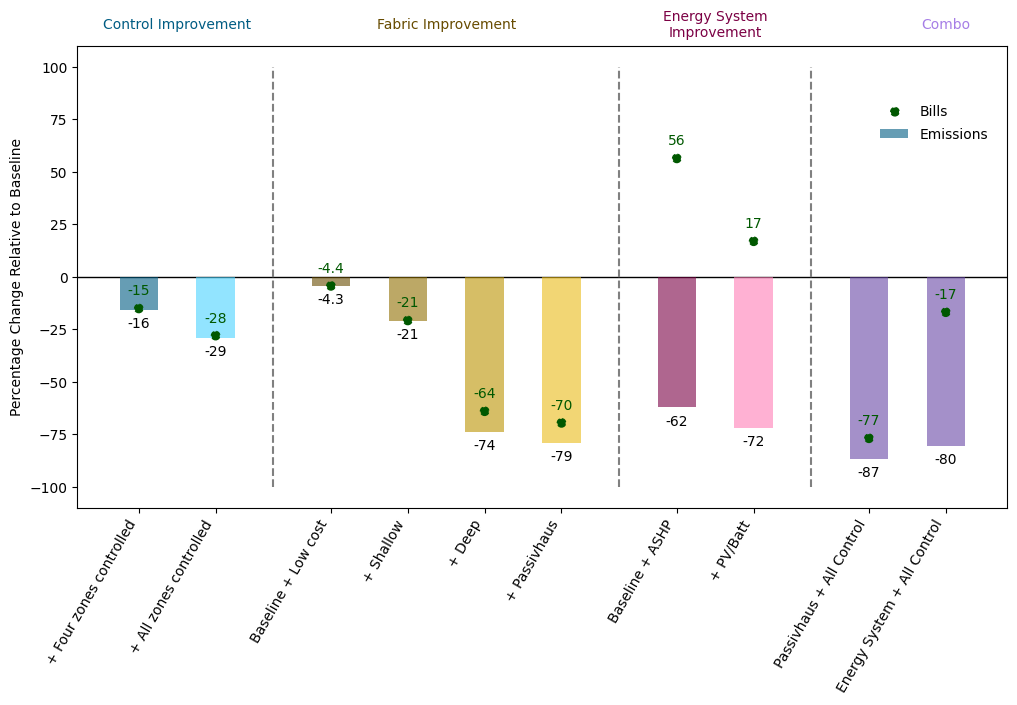

In [12]:
# Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))


control_df = df_2022[(df_2022["case"] == 0) & (df_2022["zones_controlled"] > 0)]
fabric_df = df_2022[(df_2022["case"] < 5) &  (df_2022["case"] > 0)& (df_2022["zones_controlled"] == 0)]
system_df =  df_2022[(df_2022["case"] > 4 ) &  (df_2022["case"] < 14 ) & (df_2022["zones_controlled"] == 0)]
best_df = df_2022[((df_2022["case"] == 4 ) | (df_2022["case"] == 10 )) & (df_2022["zones_controlled"] == 9)]


control = control_df["relative_emissions"]
fabric = fabric_df["relative_emissions"]
system = system_df["relative_emissions"]
best = best_df["relative_emissions"]

savings_control =control_df["relative_cost"]
savings_fabric =fabric_df["relative_cost"]
savings_system =system_df["relative_cost"]
savings_best =best_df["relative_cost"]

# Plot bars
#base = ax1.bar(np.arange(1), savings_baselines, color=intermediate_colors[0], width=0.5, alpha=0.6, label='Baseline')
cont = ax1.bar(np.arange(0,2)+0.5, control, color=intermediate_colors[1:3], width=0.5, alpha=0.6, label='Emissions')
fab = ax1.bar(np.arange(2,6)+1, fabric, color=intermediate_colors[3:7], width=0.5, alpha=0.6)
sys = ax1.bar(np.arange(6,8)+1.5, system, color=intermediate_colors[7:9], width=0.5, alpha=0.6)
bes = ax1.bar(np.arange(8,10)+2, best, color=intermediate_colors[9:10], width=0.5, alpha=0.6)

# Add data labels
for bar in cont:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height - 10, f'{height:.2g}', color='black', ha='center', va='bottom')
for bar in fab:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height - 10, f'{height:.2g}', color='black', ha='center', va='bottom')

for bar in sys:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height - 10, f'{height:.2g}', color='black', ha='center', va='bottom')

for bar in bes:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height - 10, f'{height:.2g}', color='black', ha='center', va='bottom')

# Secondary y-axis
ax2 = ax1.twinx()
#ax2.scatter(np.arange(1), baselines, color='#F0F0F0', marker='o', linestyle='--', label='Emissions')
ax2.scatter(np.arange(0,2)+0.5, savings_control, color='#005800', marker='o', linestyle='--')
ax2.scatter(np.arange(2,6)+1, savings_fabric, color='#005800', marker='o', linestyle='--')
ax2.scatter(np.arange(6,8)+1.5, savings_system, color='#005800', marker='o', linestyle='--')
ax2.scatter(np.arange(8,10)+2, savings_best, color='#005800', marker='o', linestyle='--', label='Bills')

# Add data labels for the scatter plot
def add_scatter_labels(ax, x_data, y_data):
    for (x, y) in zip(x_data, y_data):
        ax.text(x, y + 5, f'{y:.2g}', color="#005800", ha='center', va='bottom')

#add_scatter_labels(ax2, np.arange(1), baselines)
add_scatter_labels(ax2, np.arange(0,2) + 0.5, savings_control)
add_scatter_labels(ax2, np.arange(2, 6) + 1, savings_fabric)
add_scatter_labels(ax2, np.arange(6, 8) + 1.5, savings_system)
add_scatter_labels(ax2, np.arange(8, 11) + 2, savings_best)

# Add labels
plt.text(1, 120, 'Control Improvement', ha='center', va='center', color=intermediate_colors[1])
plt.text(4.5, 120, 'Fabric Improvement', ha='center', va='center', color=intermediate_colors[3])
plt.text(8, 120, 'Energy System\nImprovement', ha='center', va='center', color=intermediate_colors[7])
plt.text(11, 120, 'Combo', ha='center', va='center', color=intermediate_colors[10])
plt.xticks(ranges_concatenated, custom_labels[:-1], rotation=60, ha='right')


# Add labels
ax1.set_xticks(ranges_concatenated)
ax1.set_xticklabels(custom_labels[:-1], rotation=60, ha='right')
ax1.set_ylim([-110,110])
ax2.set_ylim([-110,110])

ax1.axhline(xmin=0, xmax=14, y=0, color="black", linestyle='-', linewidth=1, zorder=0)

# Add titles
ax1.set_ylabel('Percentage Change Relative to Baseline')
ax2.axis('off')

#ax1.vlines(x=0.75, ymin=0, ymax=100, color='gray', linestyle='--')
ax1.vlines(x=2.25, ymin=-100, ymax=100, color='gray', linestyle='--')
ax1.vlines(x=6.75, ymin=-100, ymax=100, color='gray', linestyle='--')
ax1.vlines(x=9.25, ymin=-100, ymax=100, color='gray', linestyle='--')

ax1.legend(loc='upper left', bbox_to_anchor=(0.85, 0.85), frameon=False)
ax2.legend(loc='upper right', bbox_to_anchor=(0.95, 0.9), frameon=False)
# Tightening and show
#fig.tight_layout()
#plt.savefig("reduction_potential.svg")
plt.show()

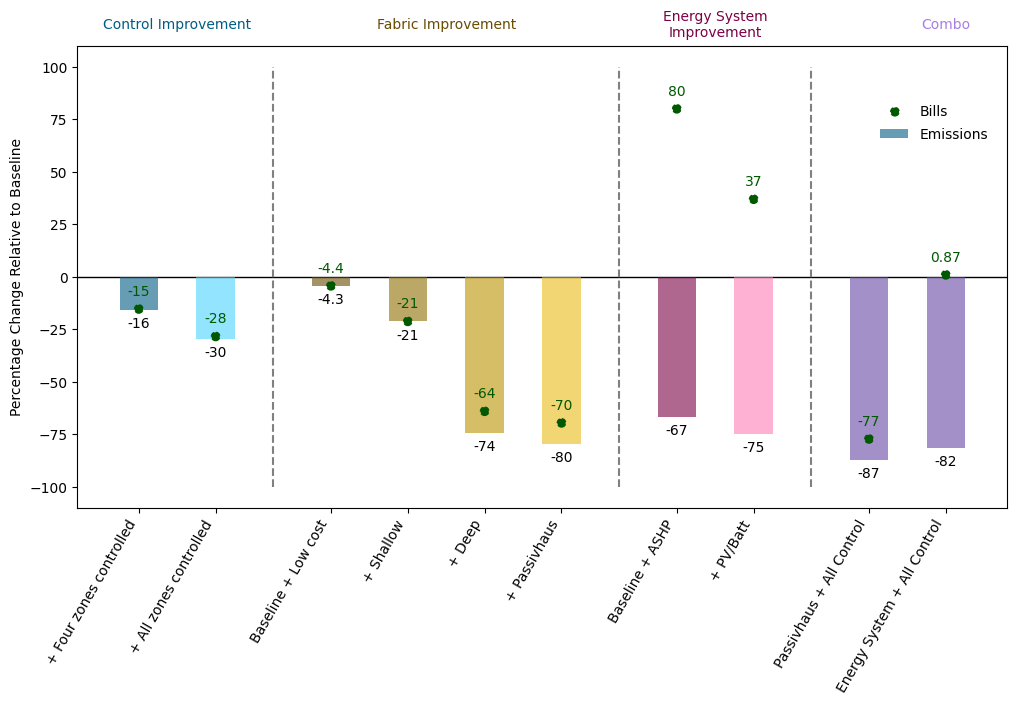

In [13]:
# Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))


control_df = df_2023[(df_2023["case"] == 0) & (df_2023["zones_controlled"] > 0)]
fabric_df = df_2023[(df_2023["case"] < 5) &  (df_2023["case"] > 0)& (df_2023["zones_controlled"] == 0)]
system_df =  df_2023[(df_2023["case"] > 4 ) &  (df_2023["case"] < 14 ) & (df_2023["zones_controlled"] == 0)]
best_df = df_2023[((df_2023["case"] == 4 ) | (df_2023["case"] == 10 )) & (df_2023["zones_controlled"] == 9)]


control = control_df["relative_emissions"]
fabric = fabric_df["relative_emissions"]
system = system_df["relative_emissions"]
best = best_df["relative_emissions"]

savings_control =control_df["relative_cost"]
savings_fabric =fabric_df["relative_cost"]
savings_system =system_df["relative_cost"]
savings_best =best_df["relative_cost"]

# Plot bars
#base = ax1.bar(np.arange(1), savings_baselines, color=intermediate_colors[0], width=0.5, alpha=0.6, label='Baseline')
cont = ax1.bar(np.arange(0,2)+0.5, control, color=intermediate_colors[1:3], width=0.5, alpha=0.6, label='Emissions')
fab = ax1.bar(np.arange(2,6)+1, fabric, color=intermediate_colors[3:7], width=0.5, alpha=0.6)
sys = ax1.bar(np.arange(6,8)+1.5, system, color=intermediate_colors[7:9], width=0.5, alpha=0.6)
bes = ax1.bar(np.arange(8,10)+2, best, color=intermediate_colors[9:10], width=0.5, alpha=0.6)

# Add data labels
for bar in cont:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height - 10, f'{height:.2g}', color='black', ha='center', va='bottom')
for bar in fab:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height - 10, f'{height:.2g}', color='black', ha='center', va='bottom')

for bar in sys:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height - 10, f'{height:.2g}', color='black', ha='center', va='bottom')

for bar in bes:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height - 10, f'{height:.2g}', color='black', ha='center', va='bottom')

# Secondary y-axis
ax2 = ax1.twinx()
#ax2.scatter(np.arange(1), baselines, color='#F0F0F0', marker='o', linestyle='--', label='Emissions')
ax2.scatter(np.arange(0,2)+0.5, savings_control, color='#005800', marker='o', linestyle='--')
ax2.scatter(np.arange(2,6)+1, savings_fabric, color='#005800', marker='o', linestyle='--')
ax2.scatter(np.arange(6,8)+1.5, savings_system, color='#005800', marker='o', linestyle='--')
ax2.scatter(np.arange(8,10)+2, savings_best, color='#005800', marker='o', linestyle='--', label='Bills')

# Add data labels for the scatter plot
def add_scatter_labels(ax, x_data, y_data):
    for (x, y) in zip(x_data, y_data):
        ax.text(x, y + 5, f'{y:.2g}', color="#005800", ha='center', va='bottom')

#add_scatter_labels(ax2, np.arange(1), baselines)
add_scatter_labels(ax2, np.arange(0,2) + 0.5, savings_control)
add_scatter_labels(ax2, np.arange(2, 6) + 1, savings_fabric)
add_scatter_labels(ax2, np.arange(6, 8) + 1.5, savings_system)
add_scatter_labels(ax2, np.arange(8, 11) + 2, savings_best)

# Add labels
plt.text(1, 120, 'Control Improvement', ha='center', va='center', color=intermediate_colors[1])
plt.text(4.5, 120, 'Fabric Improvement', ha='center', va='center', color=intermediate_colors[3])
plt.text(8, 120, 'Energy System\nImprovement', ha='center', va='center', color=intermediate_colors[7])
plt.text(11, 120, 'Combo', ha='center', va='center', color=intermediate_colors[10])
plt.xticks(np.concatenate([np.arange(0,2)+0.5, np.arange(2,6)+1, np.arange(6,8)+1.5, np.arange(8,10)+2]), custom_labels[:-1], rotation=60, ha='right')


# Add labels
ax1.set_xticks(np.concatenate([np.arange(0,2)+0.5, np.arange(2,6)+1, np.arange(6,8)+1.5, np.arange(8,10)+2]))
ax1.set_xticklabels(custom_labels[:-1], rotation=60, ha='right')
ax1.set_ylim([-110,110])
ax2.set_ylim([-110,110])

ax1.axhline(xmin=0, xmax=14, y=0, color="black", linestyle='-', linewidth=1, zorder=0)

# Add titles
ax1.set_ylabel('Percentage Change Relative to Baseline')
ax2.axis('off')

#ax1.vlines(x=0.75, ymin=0, ymax=100, color='gray', linestyle='--')
ax1.vlines(x=2.25, ymin=-100, ymax=100, color='gray', linestyle='--')
ax1.vlines(x=6.75, ymin=-100, ymax=100, color='gray', linestyle='--')
ax1.vlines(x=9.25, ymin=-100, ymax=100, color='gray', linestyle='--')

ax1.legend(loc='upper left', bbox_to_anchor=(0.85, 0.85), frameon=False)
ax2.legend(loc='upper right', bbox_to_anchor=(0.95, 0.9), frameon=False)
# Tightening and show
#fig.tight_layout()
#plt.savefig("reduction_potential.svg")
plt.show()

### Scatter plot of annual emissions vs installation cost

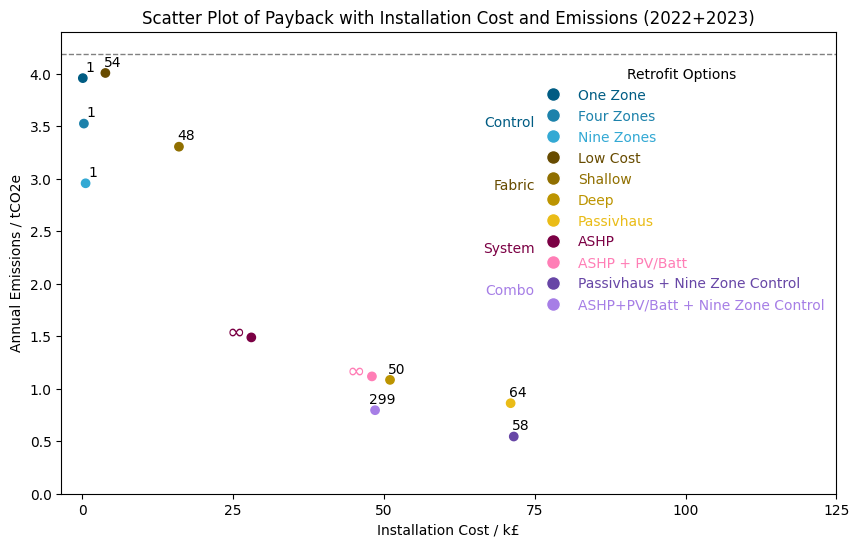

In [135]:

control_df = combined[(combined["case"] == 0) & (combined["zones_controlled"] > 0)]
fabric_df = combined[(combined["case"] < 5) &  (combined["case"] > 0)& (combined["zones_controlled"] == 0)]
system_df =  combined[(combined["case"] > 4 ) &  (combined["case"] < 14 ) & (combined["zones_controlled"] == 0)]
best_df = combined[((combined["case"] == 4 ) | (combined["case"] == 10 )) & (combined["zones_controlled"] == 9)]

plot_df = pd.concat([control_df, fabric_df, system_df, best_df])
x = plot_df['installation_cost']
y = plot_df['mean_emissions']
z = plot_df['payback']

xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(plot_df['installation_cost'], plot_df['mean_emissions'], color=intermediate_colors[1:12])

# Modify x-axis labels to show in k£
plt.xticks(ticks=np.arange(0, 130000, 25000), labels=[f'{int(x/1000)}' for x in np.arange(0, 130000, 25000)])

# Annotating each point with the payback year
count=1
for i, row in plot_df.iterrows():
    if row["relative_cost"] < 0:
        plt.annotate(f"{row['payback']:.0f}", (row['installation_cost'], row['mean_emissions']), textcoords="offset points", xytext=(5, 5), ha='center', color='black')
    else:
        plt.annotate(r"$\infty$", (row['installation_cost'], row['mean_emissions']), fontsize=16, textcoords="offset points", xytext=(-12, 0), ha='center', color=intermediate_colors[count])
    count = count + 1

plt.ylim([0,4.4])
plt.axhline(xmin=0, xmax=125000, y=combined.loc[0, "mean_emissions"], color="gray", linestyle='--', linewidth=1, zorder=0)
plt.xlabel('Installation Cost / k£')
plt.ylabel('Annual Emissions / tCO2e')
plt.title('Scatter Plot of Payback with Installation Cost and Emissions (2022+2023)')

# Create a legend with the correct colours
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=intermediate_colors[i], markersize=10) for i in range(1,12)]
labels = ['One Zone',
          'Four Zones',
          'Nine Zones',
          'Low Cost',
          'Shallow',
          'Deep',
          'Passivhaus',
          'ASHP',
          'ASHP + PV/Batt',
          'Passivhaus + Nine Zone Control',
          'ASHP+PV/Batt + Nine Zone Control'
          ]
legend_obj = plt.legend(handles, labels, title="Retrofit Options", bbox_to_anchor=(.60, 0.95), loc='upper left', frameon=False, alignment='center')

max_shift = max([t.get_window_extent().width for t in legend_obj.get_texts()])
for i,t in enumerate(legend_obj.get_texts()):
    t.set_color(intermediate_colors[i+1])
    #t.set_ha('right')  # ha is alias for horizontalalignment
    #temp_shift = max_shift - t.get_window_extent().width
    #t.set_position((temp_shift, 0))


plt.text(x=75000, y=3.5, s="Control", color=intermediate_colors[1], ha='right')
plt.text(x=75000, y=2.9, s="Fabric", color=intermediate_colors[4], ha='right')
plt.text(x=75000, y=2.3, s="System", color=intermediate_colors[8], ha='right')
plt.text(x=75000, y=1.9, s="Combo", color=intermediate_colors[11], ha='right')


plt.show()


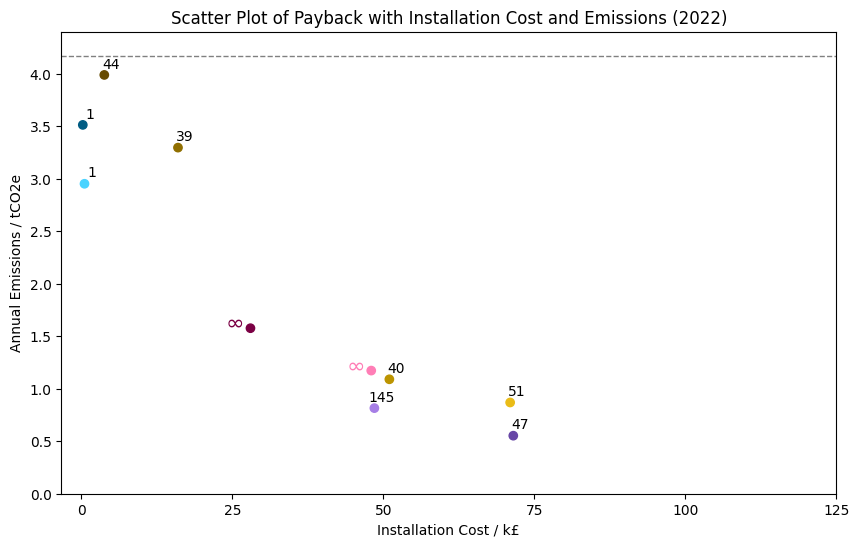

In [22]:
df = df_2022
control_df = df[(df["case"] == 0) & (df["zones_controlled"] > 0)]
fabric_df = df[(df["case"] < 5) &  (df["case"] > 0)& (df["zones_controlled"] == 0)]
system_df =  df[(df["case"] > 4 ) &  (df["case"] < 14 ) & (df["zones_controlled"] == 0)]
best_df = df[((df["case"] == 4 ) | (df["case"] == 10 )) & (df["zones_controlled"] == 9)]

plot_df = pd.concat([control_df, fabric_df, system_df, best_df])
x = plot_df['installation_cost']
y = plot_df['mean_emissions']
z = plot_df['payback']

xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(plot_df['installation_cost'], plot_df['mean_emissions'], color=intermediate_colors[1:11])

# Modify x-axis labels to show in k£
plt.xticks(ticks=np.arange(0, 130000, 25000), labels=[f'{int(x/1000)}' for x in np.arange(0, 130000, 25000)])

# Annotating each point with the payback year
count=1
for i, row in plot_df.iterrows():
    if row["relative_cost"] < 0:
        plt.annotate(f"{row['payback']:.0f}", (row['installation_cost'], row['mean_emissions']), textcoords="offset points", xytext=(5, 5), ha='center', color='black')
    else:
        plt.annotate(r"$\infty$", (row['installation_cost'], row['mean_emissions']), fontsize=16, textcoords="offset points", xytext=(-12, 0), ha='center', color=intermediate_colors[count])
    count = count + 1

plt.ylim([0,4.4])
plt.axhline(xmin=0, xmax=125000, y=df.loc[0, "mean_emissions"], color="gray", linestyle='--', linewidth=1, zorder=0)
plt.xlabel('Installation Cost / k£')
plt.ylabel('Annual Emissions / tCO2e')
plt.title('Scatter Plot of Payback with Installation Cost and Emissions (2022)')
plt.show()


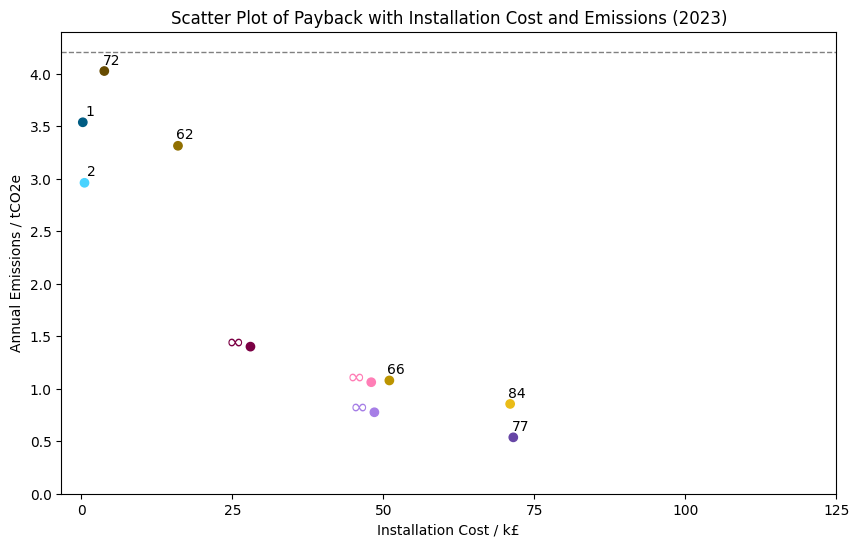

In [24]:
df = df_2023
control_df = df[(df["case"] == 0) & (df["zones_controlled"] > 0)]
fabric_df = df[(df["case"] < 5) &  (df["case"] > 0)& (df["zones_controlled"] == 0)]
system_df =  df[(df["case"] > 4 ) &  (df["case"] < 14 ) & (df["zones_controlled"] == 0)]
best_df = df[((df["case"] == 4 ) | (df["case"] == 10 )) & (df["zones_controlled"] == 9)]

plot_df = pd.concat([control_df, fabric_df, system_df, best_df])
x = plot_df['installation_cost']
y = plot_df['mean_emissions']
z = plot_df['payback']

xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(plot_df['installation_cost'], plot_df['mean_emissions'], color=intermediate_colors[1:11])

# Modify x-axis labels to show in k£
plt.xticks(ticks=np.arange(0, 130000, 25000), labels=[f'{int(x/1000)}' for x in np.arange(0, 130000, 25000)])

# Annotating each point with the payback year
count=1
for i, row in plot_df.iterrows():
    if row["relative_cost"] < 0:
        plt.annotate(f"{row['payback']:.0f}", (row['installation_cost'], row['mean_emissions']), textcoords="offset points", xytext=(5, 5), ha='center', color='black')
    else:
        plt.annotate(r"$\infty$", (row['installation_cost'], row['mean_emissions']), fontsize=16, textcoords="offset points", xytext=(-12, 0), ha='center', color=intermediate_colors[count])
    count = count + 1

plt.ylim([0,4.4])
plt.axhline(xmin=0, xmax=125000, y=df.loc[0, "mean_emissions"], color="gray", linestyle='--', linewidth=1, zorder=0)
plt.xlabel('Installation Cost / k£')
plt.ylabel('Annual Emissions / tCO2e')
plt.title('Scatter Plot of Payback with Installation Cost and Emissions (2023)')
plt.show()


### Thermal comfort analysis

In [29]:
df_2022

,case,zones_controlled,name,retrofit_name,installation_cost,mean_emissions,std_emissions,mean_cost,std_cost,mean_comfort,std_comfort,bill_saving,payback,relative_emissions,relative_emissions_std,relative_cost,relative_cost_std
0,0,0,Baseline Manual Control,Baseline,0.000,4.166,0.749,1980.180,345.492,15.850,10.966,-0.000,NaN,-0.000,17.968,0.000,17.448
1,0,4,Baseline Partial Control,Baseline,240.000,3.513,0.400,1680.285,183.236,18.001,9.488,299.894,0.800,-15.682,9.605,-15.145,9.254
2,0,9,Baseline Full Control,Baseline,520.000,2.952,0.000,1424.324,0.000,11.231,0.000,555.856,0.935,-29.143,0.000,-28.071,0.000
3,1,0,Fabric - Low cost Manual Control,Fabric - Low cost,3800.000,3.988,0.716,1893.327,329.951,15.960,11.086,86.853,43.752,-4.261,17.175,-4.386,16.663
4,1,4,Fabric - Low cost Partial Control,Fabric - Low cost,4040.000,3.360,0.385,1604.628,175.918,19.563,9.325,375.552,10.757,-19.347,9.234,-18.966,8.884
5,1,9,Fabric - Low cost Full Control,Fabric - Low cost,4320.000,2.819,0.000,1357.445,0.000,14.867,0.000,622.735,6.937,-32.345,0.000,-31.448,0.000
6,2,0,Fabric - Shallow Manual Control,Fabric - Shallow,16000.000,3.296,0.585,1567.142,269.776,15.556,11.216,413.038,38.737,-20.876,14.044,-20.859,13.624
7,2,4,Fabric - Shallow Partial Control,Fabric - Shallow,16240.000,2.765,0.318,1321.281,145.258,21.834,8.754,658.899,24.647,-33.619,7.626,-33.275,7.336
8,2,9,Fabric - Shallow Full Control,Fabric - Shallow,16520.000,2.314,0.000,1113.748,0.000,20.843,0.000,866.432,19.067,-44.464,0.000,-43.755,0.000
9,3,0,Fabric - Deep Manual Control,Fabric - Deep,51000.000,1.090,0.231,711.266,100.239,16.060,16.411,1268.914,40.192,-73.840,5.557,-64.081,5.062


In [26]:
combined

,case,zones_controlled,name,retrofit_name,installation_cost,mean_emissions,std_emissions,mean_cost,std_cost,mean_comfort,std_comfort,bill_saving,payback,relative_emissions,relative_emissions_std,relative_cost,relative_cost_std
0,0,0,Baseline Manual Control,Baseline,0.000,4.186,0.734,1594.398,483.944,16.256,10.970,-0.000,NaN,-0.000,17.541,0.000,30.353
1,0,4,Baseline Partial Control,Baseline,240.000,3.525,0.393,1351.497,368.882,18.518,9.376,242.901,0.988,-15.793,9.392,-15.235,23.136
2,0,9,Baseline Full Control,Baseline,520.000,2.957,0.005,1144.484,287.953,11.785,0.570,449.914,1.156,-29.374,0.114,-28.218,18.060
3,1,0,Fabric - Low cost Manual Control,Fabric - Low cost,3800.000,4.007,0.702,1524.610,462.386,16.374,11.094,69.788,54.451,-4.279,16.764,-4.377,29.001
4,1,4,Fabric - Low cost Partial Control,Fabric - Low cost,4040.000,3.372,0.378,1290.930,352.317,20.097,9.254,303.468,13.313,-19.461,9.034,-19.033,22.097
5,1,9,Fabric - Low cost Full Control,Fabric - Low cost,4320.000,2.823,0.004,1091.096,274.071,15.454,0.604,503.303,8.583,-32.568,0.107,-31.567,17.190
6,2,0,Fabric - Shallow Manual Control,Fabric - Shallow,16000.000,3.305,0.573,1259.387,383.271,15.787,11.109,335.011,47.760,-21.051,13.692,-21.012,24.039
7,2,4,Fabric - Shallow Partial Control,Fabric - Shallow,16240.000,2.770,0.311,1061.209,291.842,22.351,8.674,533.190,30.458,-33.829,7.441,-33.441,18.304
8,2,9,Fabric - Shallow Full Control,Fabric - Shallow,16520.000,2.313,0.000,893.715,226.412,21.449,0.624,700.683,23.577,-44.742,0.010,-43.947,14.200
9,3,0,Fabric - Deep Manual Control,Fabric - Deep,51000.000,1.084,0.228,572.699,164.598,16.241,16.026,1021.699,49.917,-74.100,5.435,-64.081,10.324


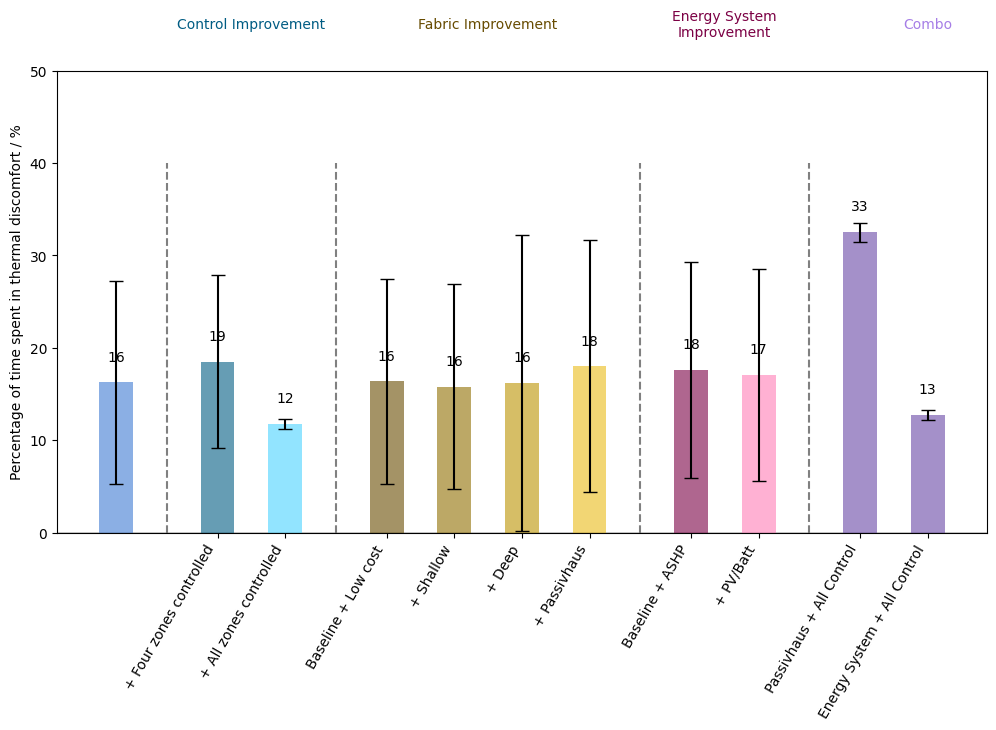

In [30]:
# Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

baseline_df = combined[(combined["case"] == 0) & (combined["zones_controlled"] == 0)]
control_df = combined[(combined["case"] == 0) & (combined["zones_controlled"] > 0)]
fabric_df = combined[(combined["case"] < 5) &  (combined["case"] > 0)& (combined["zones_controlled"] == 0)]
system_df =  combined[(combined["case"] > 4 ) &  (combined["case"] < 14 ) & (combined["zones_controlled"] == 0)]
best_df = combined[((combined["case"] == 4 ) | (combined["case"] == 10 )) & (combined["zones_controlled"] == 9)]

base = baseline_df["mean_comfort"]
control = control_df["mean_comfort"]
fabric = fabric_df["mean_comfort"]
system = system_df["mean_comfort"]
best = best_df["mean_comfort"]

base_err = baseline_df["std_comfort"]
control_err = control_df["std_comfort"]
fabric_err = fabric_df["std_comfort"]
system_err = system_df["std_comfort"]
best_err = best_df["std_comfort"]

# Plot bars with error bars
base = ax1.bar(np.arange(1), base, yerr=base_err, color=intermediate_colors[0], width=0.5, alpha=0.6, label='Baseline', capsize=5)
cont = ax1.bar(np.arange(0,2)+0.5+1, control, yerr=control_err, color=intermediate_colors[1:3], width=0.5, alpha=0.6, label='Emissions', capsize=5)
fab = ax1.bar(np.arange(2,6)+1+1, fabric, yerr=fabric_err, color=intermediate_colors[3:7], width=0.5, alpha=0.6, capsize=5)
sys = ax1.bar(np.arange(6,8)+1.5+1, system, yerr=system_err, color=intermediate_colors[7:9], width=0.5, alpha=0.6, capsize=5)
bes = ax1.bar(np.arange(8,10)+2+1, best, yerr=best_err, color=intermediate_colors[9:10], width=0.5, alpha=0.6, capsize=5)


#savings_control =control_df["relative_cost"]
#savings_fabric =fabric_df["relative_cost"]
#savings_system =system_df["relative_cost"]
#savings_best =best_df["relative_cost"]

# Add data labels
for bar in base:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height + 2, f'{height:.2g}', color='black', ha='center', va='bottom')
for bar in cont:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height + 2, f'{height:.2g}', color='black', ha='center', va='bottom')
for bar in fab:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height + 2, f'{height:.2g}', color='black', ha='center', va='bottom')

for bar in sys:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height + 2, f'{height:.2g}', color='black', ha='center', va='bottom')

for bar in bes:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height + 2, f'{height:.2g}', color='black', ha='center', va='bottom')

# Add labels
plt.text(1+1, 55, 'Control Improvement', ha='center', va='center', color=intermediate_colors[1])
plt.text(4.5+1, 55, 'Fabric Improvement', ha='center', va='center', color=intermediate_colors[3])
plt.text(8+1, 55, 'Energy System\nImprovement', ha='center', va='center', color=intermediate_colors[7])
plt.text(11+1, 55, 'Combo', ha='center', va='center', color=intermediate_colors[10])
plt.xticks(np.concatenate([np.arange(0,2)+0.5+1, np.arange(2,6)+1+1, np.arange(6,8)+1.5+1, np.arange(8,10)+2+1]), custom_labels[:-1], rotation=60, ha='right')


# Add labels
ax1.set_xticks(np.concatenate([np.arange(0,2)+0.5+1, np.arange(2,6)+1+1, np.arange(6,8)+1.5+1, np.arange(8,10)+2+1]))
ax1.set_xticklabels(custom_labels[:-1], rotation=60, ha='right')
ax1.set_ylim([0,50])
#ax2.set_ylim([-110,110])

ax1.axhline(xmin=0, xmax=14, y=0, color="black", linestyle='-', linewidth=1, zorder=0)

# Add titles
ax1.set_ylabel('Percentage of time spent in thermal discomfort / %')
#ax2.axis('off')

ax1.vlines(x=0.75, ymin=0, ymax=40, color='gray', linestyle='--')
ax1.vlines(x=3.25, ymin=0, ymax=40, color='gray', linestyle='--')
ax1.vlines(x=7.75, ymin=0, ymax=40, color='gray', linestyle='--')
ax1.vlines(x=10.25, ymin=0, ymax=40, color='gray', linestyle='--')

#ax1.legend(loc='upper left', bbox_to_anchor=(0.85, 0.85), frameon=False)
#ax2.legend(loc='upper right', bbox_to_anchor=(0.95, 0.9), frameon=False)
# Tightening and show
#fig.tight_layout()
#plt.savefig("reduction_potential.svg")
plt.show()

## Cost

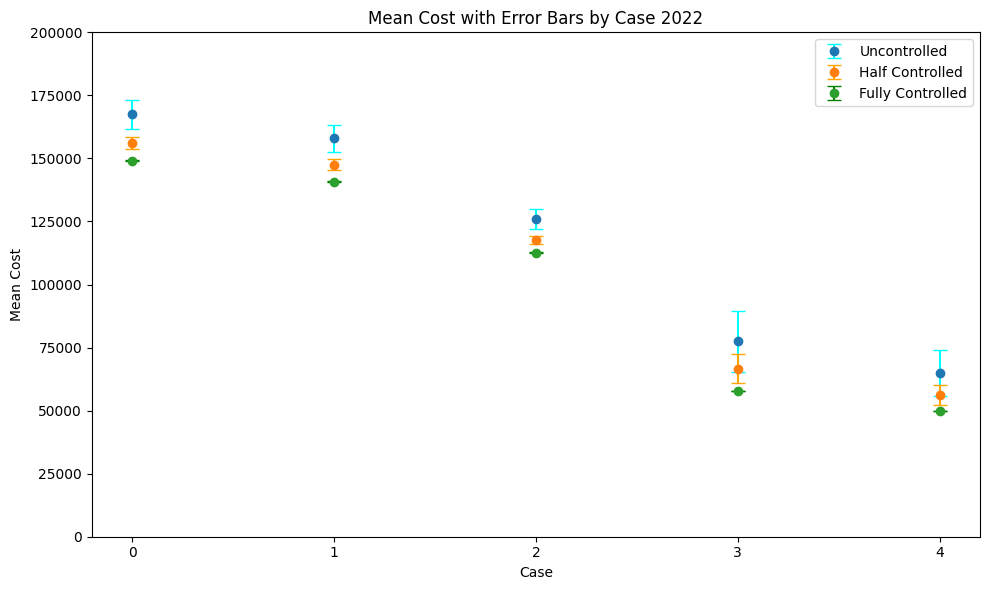

In [91]:
uncontrolled_2022 = master_df[(master_df["zones_controlled"] == 0) & (master_df["year"] == 2022) & (master_df["case"] < 5)]
halfcontrolled_2022 = master_df[(master_df["zones_controlled"] == 4) & (master_df["year"] == 2022) & (master_df["case"] < 5)]
controlled_2022 = master_df[(master_df["zones_controlled"] == 9) & (master_df["year"] == 2022) & (master_df["case"] < 5)]

cases = uncontrolled_2022['case']
uncon_mean_emissions = uncontrolled_2022['mean_cost']
uncon_std_emissions = uncontrolled_2022['std_cost']

halfcon_mean_emissions = halfcontrolled_2022['mean_cost']
halfcon_std_emissions = halfcontrolled_2022['std_cost']

con_mean_emissions = controlled_2022['mean_cost']
con_std_emissions = controlled_2022['std_cost']
# Plotting
plt.figure(figsize=(10, 6))

# Plot uncontrolled
plt.errorbar(cases, uncon_mean_emissions, yerr=uncon_std_emissions, fmt='o', capsize=5,label='Uncontrolled', ecolor='cyan')

plt.errorbar(cases, halfcon_mean_emissions, yerr=halfcon_std_emissions, fmt='o', capsize=5,label='Half Controlled', ecolor='orange')

plt.errorbar(cases, con_mean_emissions, yerr=con_std_emissions, fmt='o', capsize=5,label='Fully Controlled', ecolor='green')

plt.xlabel('Case')
plt.ylabel('Mean Cost')
plt.title('Mean Cost with Error Bars by Case 2022')
plt.ylim([0,200000])

plt.xticks(cases)  # Ensure all cases are shown on the x-axis
plt.legend()
plt.tight_layout()
plt.show()

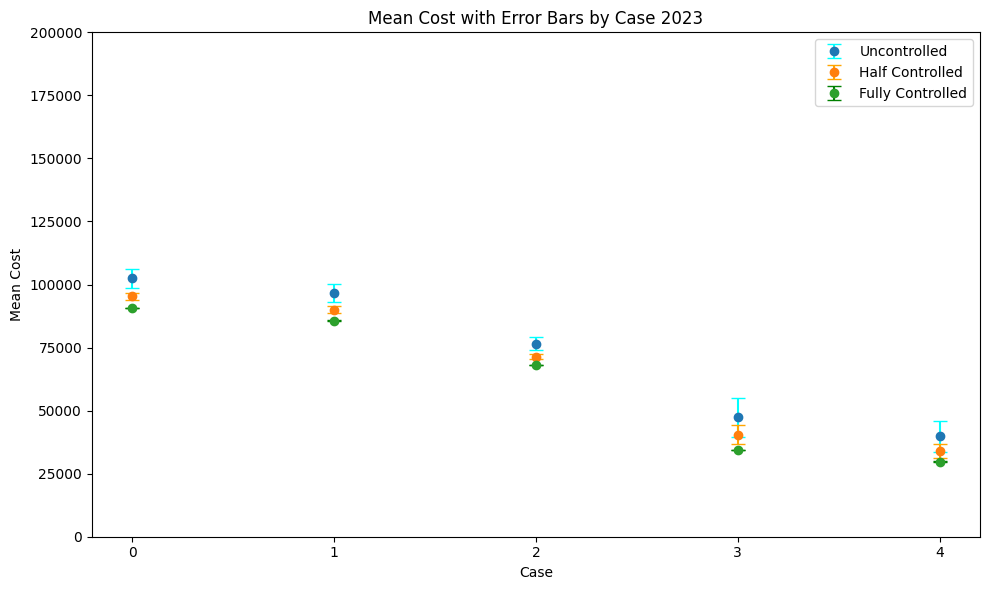

In [92]:
uncontrolled_2022 = master_df[(master_df["zones_controlled"] == 0) & (master_df["year"] == 2023) & (master_df["case"] < 5)]
halfcontrolled_2022 = master_df[(master_df["zones_controlled"] == 4) & (master_df["year"] == 2023) & (master_df["case"] < 5)]
controlled_2022 = master_df[(master_df["zones_controlled"] == 9) & (master_df["year"] == 2023) & (master_df["case"] < 5)]

cases = uncontrolled_2022['case']
uncon_mean_emissions = uncontrolled_2022['mean_cost']
uncon_std_emissions = uncontrolled_2022['std_cost']

halfcon_mean_emissions = halfcontrolled_2022['mean_cost']
halfcon_std_emissions = halfcontrolled_2022['std_cost']

con_mean_emissions = controlled_2022['mean_cost']
con_std_emissions = controlled_2022['std_cost']
# Plotting
plt.figure(figsize=(10, 6))

# Plot uncontrolled
plt.errorbar(cases, uncon_mean_emissions, yerr=uncon_std_emissions, fmt='o', capsize=5,label='Uncontrolled', ecolor='cyan')

plt.errorbar(cases, halfcon_mean_emissions, yerr=halfcon_std_emissions, fmt='o', capsize=5,label='Half Controlled', ecolor='orange')

plt.errorbar(cases, con_mean_emissions, yerr=con_std_emissions, fmt='o', capsize=5,label='Fully Controlled', ecolor='green')

plt.xlabel('Case')
plt.ylabel('Mean Cost')
plt.title('Mean Cost with Error Bars by Case 2023')
plt.ylim([0,200000])

plt.xticks(cases)  # Ensure all cases are shown on the x-axis
plt.legend()
plt.tight_layout()
plt.show()

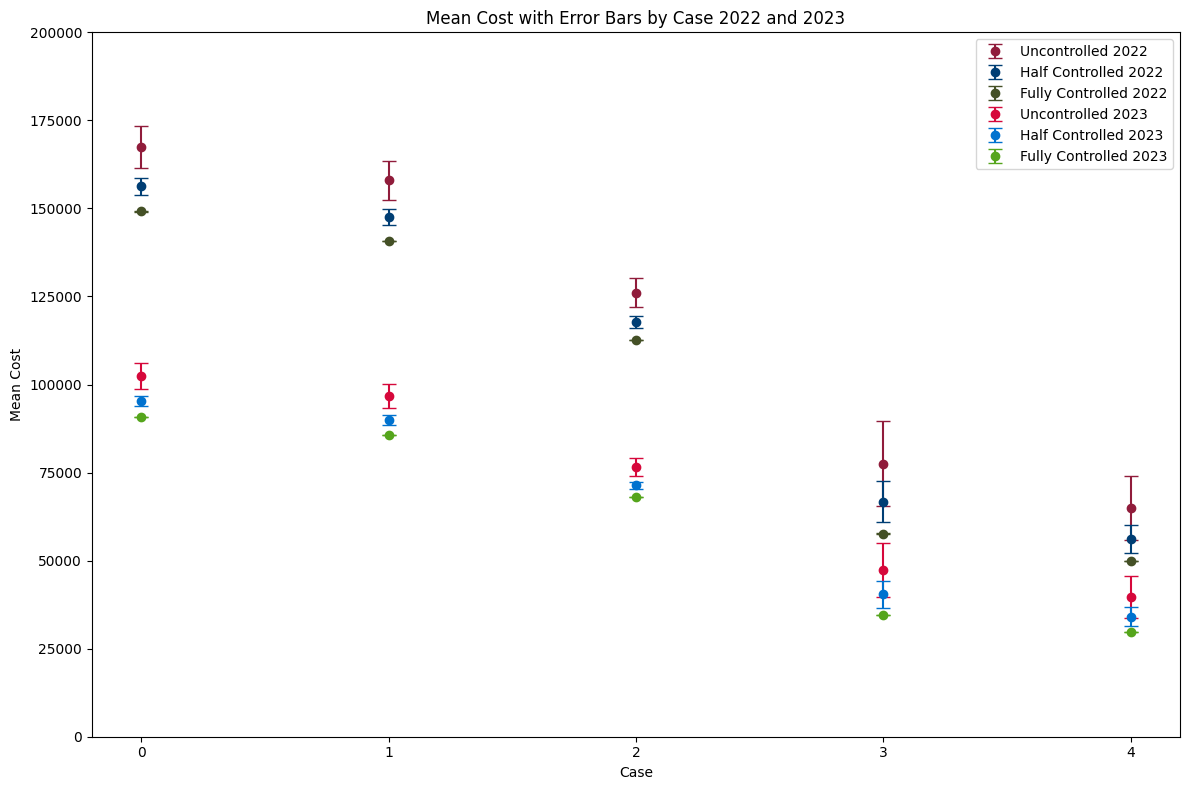

In [109]:

# Filter data for each year and control level
uncontrolled_2022 = master_df[(master_df["zones_controlled"] == 0) & (master_df["year"] == 2022) & (master_df["case"] < 5)]
halfcontrolled_2022 = master_df[(master_df["zones_controlled"] == 4) & (master_df["year"] == 2022) & (master_df["case"] < 5)]
controlled_2022 = master_df[(master_df["zones_controlled"] == 9) & (master_df["year"] == 2022) & (master_df["case"] < 5)]

uncontrolled_2023 = master_df[(master_df["zones_controlled"] == 0) & (master_df["year"] == 2023) & (master_df["case"] < 5)]
halfcontrolled_2023 = master_df[(master_df["zones_controlled"] == 4) & (master_df["year"] == 2023) & (master_df["case"] < 5)]
controlled_2023 = master_df[(master_df["zones_controlled"] == 9) & (master_df["year"] == 2023) & (master_df["case"] < 5)]

# Combine cases from both years
cases_2022 = uncontrolled_2022['case']
cases_2023 = uncontrolled_2023['case']

# Calculate mean and std for each control level and year
uncon_mean_emissions_2022 = uncontrolled_2022['mean_cost']
uncon_std_emissions_2022 = uncontrolled_2022['std_cost']

halfcon_mean_emissions_2022 = halfcontrolled_2022['mean_cost']
halfcon_std_emissions_2022 = halfcontrolled_2022['std_cost']

con_mean_emissions_2022 = controlled_2022['mean_cost']
con_std_emissions_2022 = controlled_2022['std_cost']

uncon_mean_emissions_2023 = uncontrolled_2023['mean_cost']
uncon_std_emissions_2023 = uncontrolled_2023['std_cost']

halfcon_mean_emissions_2023 = halfcontrolled_2023['mean_cost']
halfcon_std_emissions_2023 = halfcontrolled_2023['std_cost']

con_mean_emissions_2023 = controlled_2023['mean_cost']
con_std_emissions_2023 = controlled_2023['std_cost']

# Plotting
plt.figure(figsize=(12, 8))

# Plot 2022 data
plt.errorbar(cases_2022, uncon_mean_emissions_2022, yerr=uncon_std_emissions_2022, fmt='o', capsize=5, label='Uncontrolled 2022', color='#901C3B', ecolor='#901C3B')
plt.errorbar(cases_2022, halfcon_mean_emissions_2022, yerr=halfcon_std_emissions_2022, fmt='o', capsize=5, label='Half Controlled 2022', color='#003E74')
plt.errorbar(cases_2022, con_mean_emissions_2022, yerr=con_std_emissions_2022, fmt='o', capsize=5, label='Fully Controlled 2022', color='#445026')

# Plot 2023 data
plt.errorbar(cases_2023, uncon_mean_emissions_2023, yerr=uncon_std_emissions_2023, fmt='o', capsize=5, label='Uncontrolled 2023', color='#D6083B')
plt.errorbar(cases_2023, halfcon_mean_emissions_2023, yerr=halfcon_std_emissions_2023, fmt='o', capsize=5, label='Half Controlled 2023', color='#0072CF')
plt.errorbar(cases_2023, con_mean_emissions_2023, yerr=con_std_emissions_2023, fmt='o', capsize=5, label='Fully Controlled 2023', color='#55A51C')

plt.xlabel('Case')
plt.ylabel('Mean Cost')
plt.title('Mean Cost with Error Bars by Case 2022 and 2023')
plt.ylim([0, 200000])
plt.xticks(cases_2022)  # Assuming cases are the same for both years

plt.legend()
plt.tight_layout()
plt.show()


## Emissions

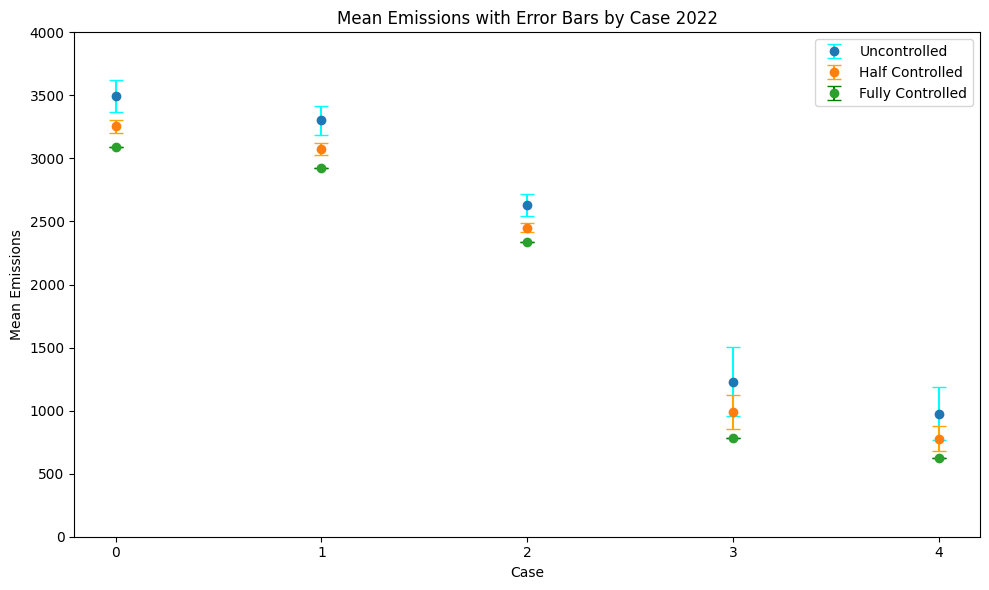

In [86]:
uncontrolled_2022 = master_df[(master_df["zones_controlled"] == 0) & (master_df["year"] == 2022) & (master_df["case"] < 5)]
halfcontrolled_2022 = master_df[(master_df["zones_controlled"] == 4) & (master_df["year"] == 2022) & (master_df["case"] < 5)]
controlled_2022 = master_df[(master_df["zones_controlled"] == 9) & (master_df["year"] == 2022) & (master_df["case"] < 5)]

cases = uncontrolled_2022['case']
uncon_mean_emissions = uncontrolled_2022['mean_emissions']
uncon_std_emissions = uncontrolled_2022['std_emissions']

halfcon_mean_emissions = halfcontrolled_2022['mean_emissions']
halfcon_std_emissions = halfcontrolled_2022['std_emissions']

con_mean_emissions = controlled_2022['mean_emissions']
con_std_emissions = controlled_2022['std_emissions']
# Plotting
plt.figure(figsize=(10, 6))

# Plot uncontrolled
plt.errorbar(cases, uncon_mean_emissions, yerr=uncon_std_emissions, fmt='o', capsize=5,label='Uncontrolled', ecolor='cyan')

plt.errorbar(cases, halfcon_mean_emissions, yerr=halfcon_std_emissions, fmt='o', capsize=5,label='Half Controlled', ecolor='orange')

plt.errorbar(cases, con_mean_emissions, yerr=con_std_emissions, fmt='o', capsize=5,label='Fully Controlled', ecolor='green')

plt.xlabel('Case')
plt.ylabel('Mean Emissions')
plt.title('Mean Emissions with Error Bars by Case 2022')
plt.ylim([0,4000])

plt.xticks(cases)  # Ensure all cases are shown on the x-axis
plt.legend()
plt.tight_layout()
plt.show()

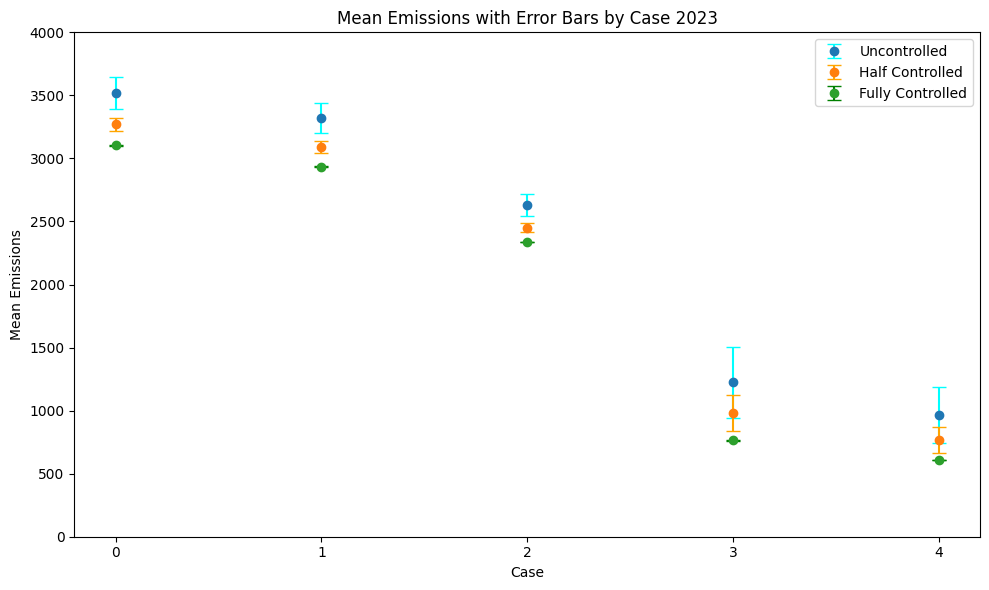

In [87]:
uncontrolled_2023 = master_df[(master_df["zones_controlled"] == 0) & (master_df["year"] == 2023) & (master_df["case"] < 5)]
halfcontrolled_2023 = master_df[(master_df["zones_controlled"] == 4) & (master_df["year"] == 2023) & (master_df["case"] < 5)]
controlled_2023 = master_df[(master_df["zones_controlled"] == 9) & (master_df["year"] == 2023) & (master_df["case"] < 5)]

cases = uncontrolled_2023['case']
uncon_mean_emissions = uncontrolled_2023['mean_emissions']
uncon_std_emissions = uncontrolled_2023['std_emissions']

halfcon_mean_emissions = halfcontrolled_2023['mean_emissions']
halfcon_std_emissions = halfcontrolled_2023['std_emissions']

con_mean_emissions = controlled_2023['mean_emissions']
con_std_emissions = controlled_2023['std_emissions']
# Plotting
plt.figure(figsize=(10, 6))

# Plot uncontrolled
plt.errorbar(cases, uncon_mean_emissions, yerr=uncon_std_emissions, fmt='o', capsize=5, label='Uncontrolled', ecolor='cyan')

plt.errorbar(cases, halfcon_mean_emissions, yerr=halfcon_std_emissions, fmt='o', capsize=5, label='Half Controlled', ecolor='orange')

plt.errorbar(cases, con_mean_emissions, yerr=con_std_emissions, fmt='o', capsize=5, label='Fully Controlled', ecolor='green')

plt.xlabel('Case')
plt.ylabel('Mean Emissions')
plt.title('Mean Emissions with Error Bars by Case 2023')
plt.ylim([0,4000])

plt.xticks(cases)  # Ensure all cases are shown on the x-axis
plt.legend()
plt.tight_layout()
plt.show()

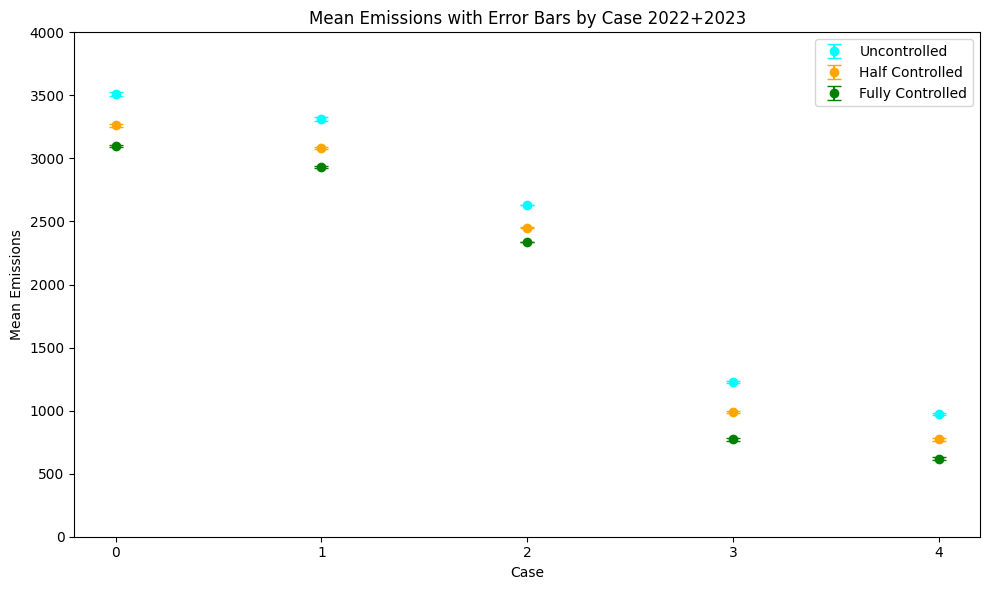

In [83]:
# Filter data for different control levels
uncontrolled = master_df[(master_df["zones_controlled"] == 0) & (master_df["case"] < 5)]
halfcontrolled = master_df[(master_df["zones_controlled"] == 4) & (master_df["case"] < 5)]
controlled = master_df[(master_df["zones_controlled"] == 9) & (master_df["case"] < 5)]

cases = uncontrolled['case'].unique()

# Calculate mean and std for each control level
uncon_mean_emissions = uncontrolled.groupby('case')['mean_emissions'].mean()
uncon_std_emissions = uncontrolled.groupby('case')['mean_emissions'].std()

halfcon_mean_emissions = halfcontrolled.groupby('case')['mean_emissions'].mean()
halfcon_std_emissions = halfcontrolled.groupby('case')['mean_emissions'].std()

con_mean_emissions = controlled.groupby('case')['mean_emissions'].mean()
con_std_emissions = controlled.groupby('case')['mean_emissions'].std()

# Plotting
plt.figure(figsize=(10, 6))

# Plot uncontrolled
plt.errorbar(cases, uncon_mean_emissions, yerr=uncon_std_emissions, fmt='o', capsize=5, label='Uncontrolled', color='cyan')

# Plot half controlled
plt.errorbar(cases, halfcon_mean_emissions, yerr=halfcon_std_emissions, fmt='o', capsize=5, label='Half Controlled', color='orange')

# Plot fully controlled
plt.errorbar(cases, con_mean_emissions, yerr=con_std_emissions, fmt='o', capsize=5, label='Fully Controlled', color='green')

plt.xlabel('Case')
plt.ylabel('Mean Emissions')
plt.title('Mean Emissions with Error Bars by Case 2022+2023')
plt.ylim([0, 4000])

plt.xticks(cases)  # Ensure all cases are shown on the x-axis
plt.legend()
plt.tight_layout()
plt.show()

#### Scrap

In [ ]:
master_df = pd.read_csv("/workspaces/CUBES/exp/jack/paper/thermostat_experiment/Eplus_files/final_runs_v0/final_runs_v0.csv",index_col=0)

# Define building_cost_df
building_cost = {
    'case': [0, 1, 2, 3, 4, 5, 10],
    'building_cost': [0, 3800, 16000, 51000, 71000, 28000, 48000]
}
building_cost_df = pd.DataFrame(building_cost)

# Define sensing_cost_df
sensing_cost = {
    'zones_controlled': [0, 4, 9],
    'sensing_cost': [0, 240, 520],
    'control_names': ["Manual Control", "Partial Control", "Full Control"]
}
sensing_cost_df = pd.DataFrame(sensing_cost)

# Define sensing_cost_df
case_names = {
    'case': [0, 1, 2, 3, 4, 5, 10],
    'retrofit_name': ["Baseline", "Fabric - Low cost", "Fabric - Shallow", "Fabric - Deep", "Fabric - Passivhaus", "System - ASHP", "System - ASHP+PV+Batt"],
}
case_names_df = pd.DataFrame(case_names)

# Merge building_cost_df with master_df
merged_df = pd.merge(master_df, building_cost_df, on='case', how='left')

# Merge sensing_cost_df with merged_df
merged_df = pd.merge(merged_df, sensing_cost_df, on='zones_controlled', how='left')

merged_df = pd.merge(merged_df, case_names_df, on='case', how='left')

# Optionally, rename columns if needed
merged_df.rename(columns={'building_cost_x': 'building_cost'}, inplace=True)


merged_df["installation_cost"] = merged_df["building_cost"] + merged_df["sensing_cost"]

merged_df["name"] = merged_df['retrofit_name'] + " " + merged_df['control_names']

df_2022 = merged_df[merged_df["year"] == 2022]
df_2023 = merged_df[merged_df["year"] == 2023]

df_2022 = df_2022.reset_index()
df_2023 = df_2023.reset_index()


df_2022 = df_2022.groupby(
["case", "zones_controlled", "name", "retrofit_name", "installation_cost"]
    ).agg(
        mean_emissions=('cumulative_emissions', 'mean'),
        std_emissions=('cumulative_emissions', 'std'),
        #mean_relative_emissions=('relative_emissions', 'mean'),
        mean_cost=('cost', 'mean'),
        std_cost=('cost', 'std'),
        #mean_relative_cost=('relative_cost', 'mean'),
        mean_comfort=('comfort_violation (%)', 'mean'),
        std_comfort=('comfort_violation (%)', 'std')
    ).reset_index()

df_2023 = df_2023.groupby(
["case", "zones_controlled", "name", "retrofit_name", "installation_cost"]
    ).agg(
        mean_emissions=('cumulative_emissions', 'mean'),
        std_emissions=('cumulative_emissions', 'std'),
        #mean_relative_emissions=('relative_emissions', 'mean'),
        mean_cost=('cost', 'mean'),
        std_cost=('cost', 'std'),
        #mean_relative_cost=('relative_cost', 'mean'),
        mean_comfort=('comfort_violation (%)', 'mean'),
        std_comfort=('comfort_violation (%)', 'std')
    ).reset_index()



In [137]:
controlled = combined.iloc[:4,:]
controlled

,case,zones_controlled,name,retrofit_name,installation_cost,mean_emissions,std_emissions,mean_cost,std_cost,mean_comfort,std_comfort,bill_saving,payback,relative_emissions,relative_emissions_std,relative_cost,relative_cost_std
0,0,0,Baseline Manual Control,Baseline,0.0,4.2,0.7,1594.4,483.9,16.3,11.0,-0.0,NaN,-0.0,17.5,0.0,30.4
1,0,1,Baseline One Zone Controlled,Baseline,60.0,4.0,0.6,1509.6,447.2,17.1,10.9,84.8,0.7,-5.4,15.3,-5.3,28.0
2,0,4,Baseline Partial Control,Baseline,240.0,3.5,0.4,1351.5,368.9,18.5,9.4,242.9,1.0,-15.8,9.4,-15.2,23.1
3,0,9,Baseline Full Control,Baseline,520.0,3.0,0.0,1144.5,288.0,11.8,0.6,449.9,1.2,-29.4,0.1,-28.2,18.1


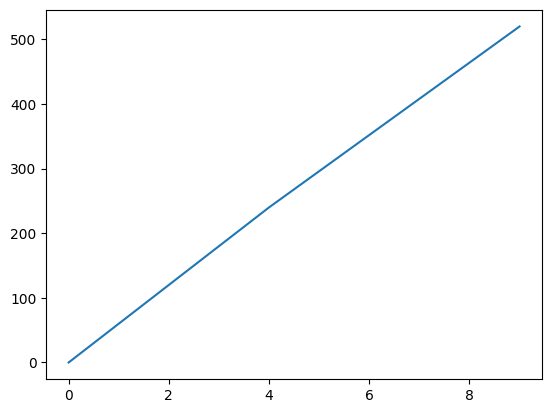

In [138]:
plt.plot(controlled['zones_controlled'], controlled['installation_cost'])